<a href="https://colab.research.google.com/github/sheliter/Assignment/blob/main/Homework_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Set a4a to the pair (L2_lambda_64,L2_lambda_32) of the L2 lambdas for the two hidden layers which provided the best
# validation accuracy at the epoch of minimum validation loss

a4a = (0.0,0.0)             # Replace (0.0,0.0) with your answer

# Homework 03: Learning Curves and Training Workflow

**Points:** 85

In this assignment, you will learn how to design, train, and evaluate neural networks by systematically exploring key design choices. Your focus will be on developing an effective **training workflow** — using learning curves and validation metrics to guide your decisions.

We'll use the **Forest Cover Type (Covertype) dataset,** which has ~581k tabular records with 54 cartographic/topographic features (elevation, aspect, slope, soil and wilderness indicators) used to predict one of seven tree cover types in Colorado’s Roosevelt National Forest. It’s a large, mildly imbalanced multi-class benchmark commonly used to compare classical ML and deep learning on tabular data.

We will start with a **baseline model** (two hidden layers of sizes 64 and 32), and gradually introduce and tune different hyperparameters. Each of the first five problems considers  different hyperparameter choices, and the last problem is your chance to use what you have learned to design your best model:

1. **Activation function** – Compare ReLU, sigmoid, and tanh to see which provides the best accuracy.
2. **Learning rate** – Explore a range of learning rates and identify which balances convergence speed and stability.
3. **Dropout** – Investigate how different dropout rates reduce overfitting and where they are most effective.
4. **L2 regularization** – Experiment with weight penalties to encourage simpler models and avoid memorization.
5. **Dropout + L2** – Combine both regularization techniques and study their interaction.
6. **Best model design** – Use all your insights to build and train your strongest model, with the option to try **learning rate scheduling** for further improvement.

In this homework, you will use **early stopping** to select the "best" model at the epoch of **minimum validation loss**, and you will report the **validation accuracy** of that selected model as the primary measure of performance. Test accuracy is reported for reference but is not used for model selection.

> **Note:** Throughout this homework, best always refers to the model selected by early stopping at the epoch of minimum validation loss. Do not report metrics from the final training epoch unless explicitly instructed.

By the end of this homework, you will not only understand how different hyperparameters affect training and generalization, but also gain hands-on practice in building a disciplined workflow for model development.

There are 10 graded problems, worth 8 points each, with 5 points for free if you complete the homework.

In [ ]:
# Useful imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import time
import os

from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.utils import class_weight

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input,Dropout
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers.schedules import ExponentialDecay


from tensorflow.keras.datasets import fashion_mnist

# utility code

random_seed = 42

def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Suppresses INFO and WARNING messages


In [ ]:
# Utility function to plot learning curves and keep track of all results

# Call `print_results()` to see listing of all results logged so far


def plot_learning_curves(hist, title, verbose=True):

    val_losses = hist.history['val_loss']
    min_val_loss = min(val_losses)
    min_val_epoch = val_losses.index(min_val_loss)
    val_acc_at_min_loss = hist.history['val_accuracy'][min_val_epoch]

    epochs = range(1, len(val_losses) + 1)  # epoch numbers starting at 1

    fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

    # --- Loss Plot ---
    axs[0].plot(epochs, hist.history['loss'], label='train loss')
    axs[0].plot(epochs, hist.history['val_loss'], label='val loss')
    axs[0].scatter(min_val_epoch + 1, min_val_loss, color='red', marker='x', s=50, label='min val loss')
    axs[0].set_title(f'{title} - Categorical Cross-Entropy Loss')
    axs[0].set_ylabel('Loss')
    axs[0].legend()
    axs[0].grid(True)

    # --- Accuracy Plot ---
    axs[1].plot(epochs, hist.history['accuracy'], label='train acc')
    axs[1].plot(epochs, hist.history['val_accuracy'], label='val acc')
    axs[1].scatter(min_val_epoch + 1, val_acc_at_min_loss, color='red', marker='x', s=50, label='acc @ min val loss')
    axs[1].set_title(f'{title} - Accuracy')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Accuracy')
    axs[1].legend()
    axs[1].grid(True)
    axs[1].set_ylim(0, 1.05)

    plt.tight_layout()
    plt.show()

    if verbose:
        print(f"Final Training Loss:            {hist.history['loss'][-1]:.4f}")
        print(f"Final Training Accuracy:        {hist.history['accuracy'][-1]:.4f}")
        print(f"Final Validation Loss:          {hist.history['val_loss'][-1]:.4f}")
        print(f"Final Validation Accuracy:      {hist.history['val_accuracy'][-1]:.4f}")
        print(f"Minimum Validation Loss:        {min_val_loss:.4f} (Epoch {min_val_epoch + 1})")
        print(f"Validation Accuracy @ Min Loss: {val_acc_at_min_loss:.4f}")

    results[title] = (val_acc_at_min_loss,min_val_epoch + 1)

results = {}

**The plotting function will record the validation accuracy for each experiment, using the plot title as key. The next function will print these out (see the last cell in the notebook).**


In order to see all results, you must give a different plot title to each experiment.

In [ ]:
def print_results():
    for title, (acc, ep) in sorted(results.items(),
                                   key=lambda kv: kv[1][0],   # kv[1] is (acc, epoch); [0] is acc
                                   reverse=True
                                  ):
        print(f"{title:<40}\t{acc:.4f}")

### Wrapper to train, display results, and run test set

We assume multi-class classification, and allow setting various parameters for training.

In [ ]:
# Uses globals X_train,y_train,X_val,y_val

def train_and_test(model,
                   epochs        = 500,                   # Just needs to be bigger than early stop point
                   lr_schedule   = 0.001,                 # Adam default / 10 seems to work well for this dataset
                   optimizer     = "Adam",
                   title         = "Learning Curves",
                   batch_size    = 64,                     # experiments confirmed this was optimal with other parameters at default
                   use_early_stopping = True,
                   patience      = 10,
                   min_delta     = 0.0001,
                   callbacks     = [],                     # for extra callbacks other than early stopping
                   verbose       = 0,
                   return_history = False
                  ):

    print(f"\n{title}\n")


    if optimizer == "Adam":
        opt = Adam(learning_rate=lr_schedule)
    else:
        opt = optimizer

    #Compiling the model
    model.compile(optimizer=opt,
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"]
                 )

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=patience,
        min_delta=min_delta,
        restore_best_weights=True,               # this will mean that the model which produced the smallest validation loss will be returned
        verbose=verbose
    )


    if use_early_stopping:
        cbs=[early_stop] + callbacks
    else:
        cbs=callbacks

    # start timer
    start = time.time()

    # Fit the model with early stopping
    history = model.fit(X_train, y_train,
                        epochs=epochs,
                        batch_size=batch_size,
                        validation_data=(X_val, y_val),       # must use stratified validation set
                        callbacks=cbs,
                        verbose=verbose
                       )

    if use_early_stopping:
        best_epoch = early_stop.best_epoch
        best_acc   = history.history['val_accuracy'][best_epoch]
    else:
        best_epoch = np.argmax(history.history['val_accuracy'])
        best_acc   = history.history['val_accuracy'][best_epoch]

    # Plot training history
    plot_learning_curves(history, title=title)

    # Evaluate on test data
    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

    print(f"\nTest Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")

    print(f"\nValidation-Test Gap (accuracy): {abs(best_acc - test_accuracy):.6f}")

    # Record end time and print execution time
    end = time.time()
    print(f"\nExecution Time: " + format_hms(end-start))

    if return_history:
        return history

### Load the dataset and extract a stratified subset

This data set is rather large (581,012 samples) and unbalanced, but for the purposes of this homework, we use a much smaller set, and select samples so that it is balanced.

In [ ]:
# complete cell: load, balance, split into X_train/y_train/x_val/y_val/X_test/y_test, and standardize
from collections import Counter
from sklearn.datasets import fetch_covtype
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# 1) load
x, y = fetch_covtype(return_X_y=True)  # y in {1..7}
print("full dataset shape:", x.shape)

# 2) build a perfectly balanced subset across 7 classes (no replacement)
classes, counts = np.unique(y, return_counts=True)
# min_count = counts.min()  # size of rarest class                         # You can modify this parameter to increase the size of the dataset, but above
min_count = 1000                                                           # counts.min() you'll produce an unbalanced set.


rng = np.random.default_rng(42)

idx_list = []
for c in classes:
    c_idx = np.where(y == c)[0]
    chosen = rng.choice(c_idx, size=min_count, replace=False)
    idx_list.append(chosen)

idx_bal = np.concatenate(idx_list)
rng.shuffle(idx_bal)

X_sub = x[idx_bal]
y_sub = y[idx_bal] - 1  # relabel to {0..6} for keras
print("balanced subset shape:", X_sub.shape, "class counts:", dict(Counter(y_sub)))

# 3) stratified 60/20/20 split (train/val/test)
test_size = 0.20
val_size = 0.20  # of the whole dataset

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_sub, y_sub, test_size=test_size, random_state=random_seed, stratify=y_sub
)
val_size_rel = val_size / (1.0 - test_size)  # e.g., 0.20 / 0.80 = 0.25

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=val_size_rel, random_state=random_seed, stratify=y_trainval
)

# 4) standardize using train-only stats (float32 for tensorflow friendliness)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_val   = scaler.transform(X_val).astype(np.float32)
X_test  = scaler.transform(X_test).astype(np.float32)

# 5) quick sanity checks
def show_counts(name, y_arr):
    c = Counter(y_arr)
    total = sum(c.values())
    print(f"{name}: total={total}, per-class={dict(c)}")

print("shapes:", "X_train", X_train.shape, "X_val", X_val.shape, "X_test", X_test.shape)
show_counts("train", y_train)
show_counts("val  ", y_val)
show_counts("test ", y_test)

# you now have: X_train, y_train, X_val, y_val, X_test, y_test

# Looks like integer encoded multi-class, let's check and define the global n_classes

labels = np.unique(y_train)

n_classes = len(labels)

print("class labels:",labels)


full dataset shape: (581012, 54)
balanced subset shape: (7000, 54) class counts: {np.int32(2): 1000, np.int32(0): 1000, np.int32(4): 1000, np.int32(5): 1000, np.int32(1): 1000, np.int32(3): 1000, np.int32(6): 1000}
shapes: X_train (4200, 54) X_val (1400, 54) X_test (1400, 54)
train: total=4200, per-class={np.int32(2): 600, np.int32(1): 600, np.int32(0): 600, np.int32(3): 600, np.int32(5): 600, np.int32(4): 600, np.int32(6): 600}
val  : total=1400, per-class={np.int32(1): 200, np.int32(6): 200, np.int32(5): 200, np.int32(4): 200, np.int32(3): 200, np.int32(2): 200, np.int32(0): 200}
test : total=1400, per-class={np.int32(0): 200, np.int32(6): 200, np.int32(2): 200, np.int32(3): 200, np.int32(4): 200, np.int32(5): 200, np.int32(1): 200}
class labels: [0 1 2 3 4 5 6]


## Prelude: Defining a model builder

In order to facilitate our experimentation, we'll write a function which builds models according to specifications:

- How many layers
- How wide each layer is
- How much dropout in each layer
- How much L2 Regularization in each layer

This is a fairly standard practice in ML, since the structure of simple models is fairly predictable and can be specified by a few hyperparameters.

In [ ]:
# This function will build a multi-class classifier with dropout and L2 regularization.
# You must specify the number of input features, the number of classes, and a list of layer hyperparameters
# in the form  [ ...., (width, activation function, L2 lambda, dropout rate), .... ]

# Note that when adding dropout, this appears as a separate layer, but it has no parameters to be trained.

def build_model(n_inputs,layer_list,n_classes):
    layers = [ Input(shape=(n_inputs,)) ]
    for (width,act,l2_lambda,dropout_rate) in layer_list:
        layers.append( Dense(width, activation=act, kernel_regularizer=regularizers.l2(l2_lambda)) )
        if dropout_rate > 0:
            layers.append( Dropout(dropout_rate) )
    layers.append( Dense(n_classes, activation='softmax') )
    return models.Sequential( layers )


**Example: To build the following model:**

In [ ]:
model = models.Sequential(
   [
    Input(shape=(X_train.shape[1],)),
    Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.0)),              # 0.0 means no regularization applied; no dropout, so no Dropout layer necessary
    Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.3),
    Dense(n_classes, activation='softmax')
   ]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         3,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,831 (22.78 KB)

 Trainable params: 5,831 (22.78 KB)

 Non-trainable params: 0 (0.00 B)

**We call `build_model` as shown here:**

In [ ]:
build_model(X_train.shape[1], [ (64,'relu',0.0,0.0), (32,'relu',0.001,0.3)], n_classes).summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         3,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,831 (22.78 KB)

 Trainable params: 5,831 (22.78 KB)

 Non-trainable params: 0 (0.00 B)

-------------------



### Baseline Model Architecture

**Problems 1–5 will use the following baseline model structure,** implemented with the provided `build_model` function and trained using `train_and_test`:

```
input → 64 → 32 → output
```

* Two hidden layers of widths 64 and 32.
* Activation function, dropout rate, and L2 regularization term (λ) will vary as specified in each problem.
* **Early stopping** is always applied to select the model at the epoch of **minimum validation loss**.
* We will report the **validation accuracy** of the selected model as the primary metric.


### Problem One: Which Activation Function?

In this problem, you will train the **baseline neural network** and investigate which activation function produces the best performance. The model you create will be the one saved by **early stopping** — that is, the epoch where validation loss is minimized.

**Steps to follow:**

* Use the provided functions `train_and_test` and `build_model` to create a model named **`model_baseline`**.
* Train and evaluate this model using each of the following activation functions in the hidden layers:

  * `relu`
  * `sigmoid`
  * `tanh`
* Identify which activation function produces the **best validation accuracy** at the epoch of **minimum validation loss**.
* Answer the graded questions.



=== Experiment 0: Baseline - activation=relu ===

Baseline - activation=relu



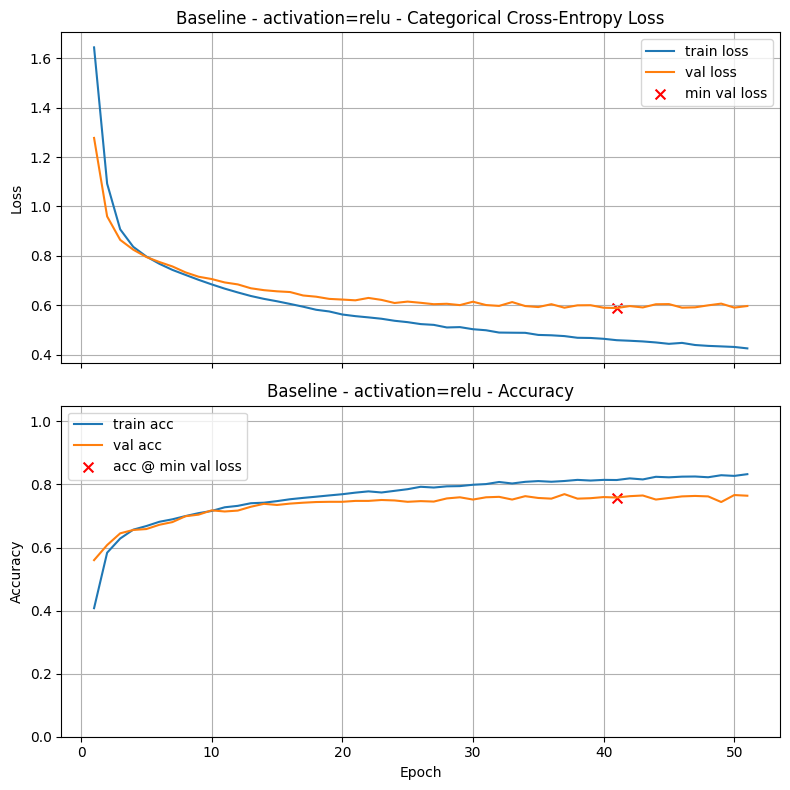

Final Training Loss:            0.4252
Final Training Accuracy:        0.8326
Final Validation Loss:          0.5968
Final Validation Accuracy:      0.7643
Minimum Validation Loss:        0.5885 (Epoch 41)
Validation Accuracy @ Min Loss: 0.7586

Test Loss: 0.6086
Test Accuracy: 0.7579

Validation-Test Gap (accuracy): 0.000714

Execution Time: 00:00:25

=== Experiment 1: Baseline - activation=sigmoid ===

Baseline - activation=sigmoid



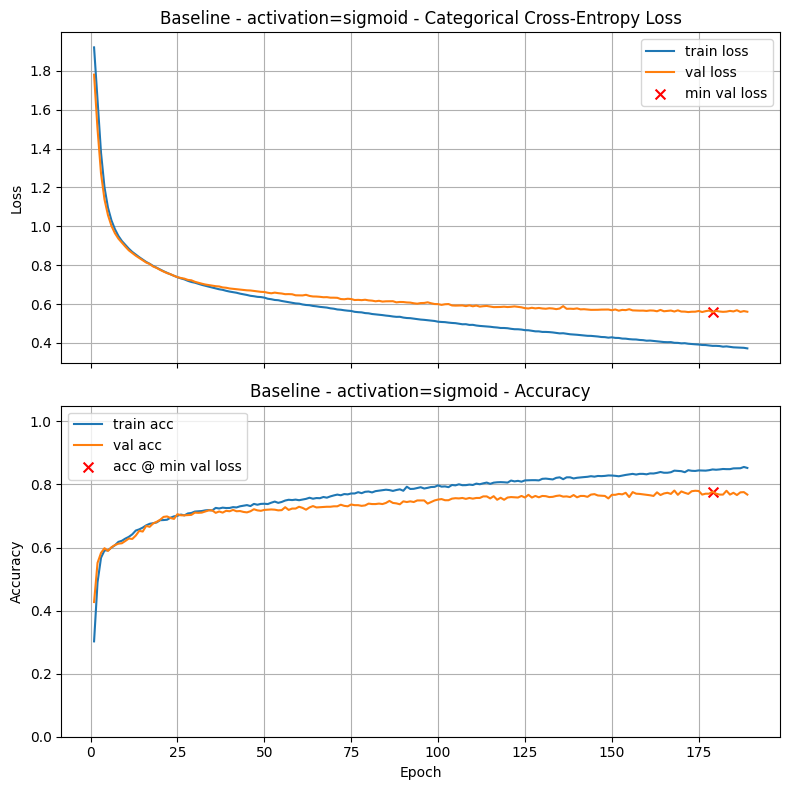

Final Training Loss:            0.3723
Final Training Accuracy:        0.8524
Final Validation Loss:          0.5607
Final Validation Accuracy:      0.7679
Minimum Validation Loss:        0.5589 (Epoch 179)
Validation Accuracy @ Min Loss: 0.7771

Test Loss: 0.5706
Test Accuracy: 0.7729

Validation-Test Gap (accuracy): 0.004286

Execution Time: 00:01:22

=== Experiment 2: Baseline - activation=tanh ===

Baseline - activation=tanh



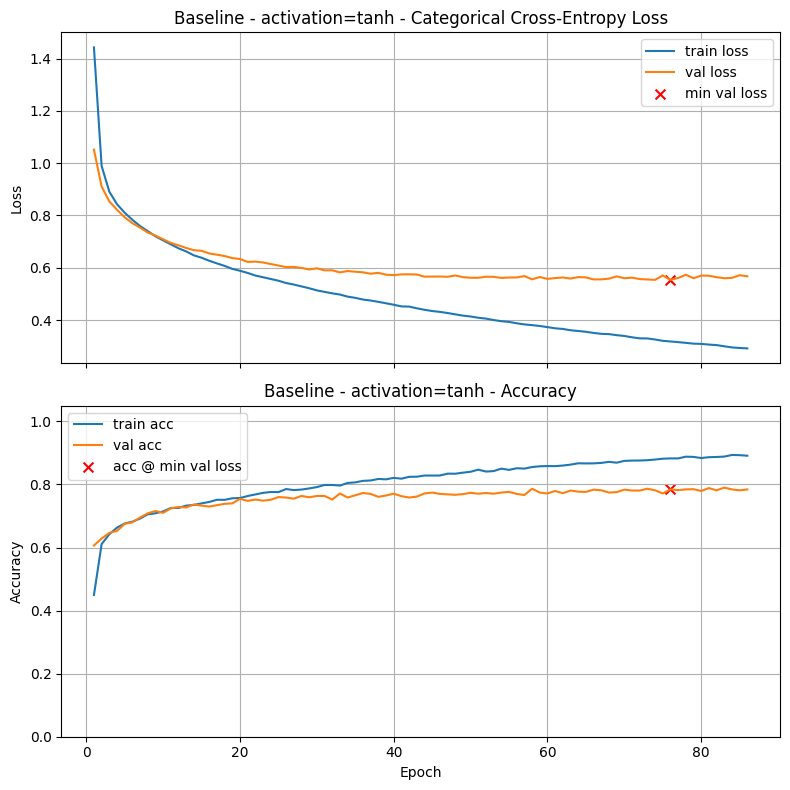

Final Training Loss:            0.2915
Final Training Accuracy:        0.8912
Final Validation Loss:          0.5673
Final Validation Accuracy:      0.7843
Minimum Validation Loss:        0.5535 (Epoch 76)
Validation Accuracy @ Min Loss: 0.7843

Test Loss: 0.5606
Test Accuracy: 0.7771

Validation-Test Gap (accuracy): 0.007143

Execution Time: 00:01:03


In [ ]:
# Your code here. Add as many cells as you need.
activations = ['relu', 'sigmoid', 'tanh']
histories = {}
titles = []

for i, act in enumerate(activations):
    title = f"Baseline - activation={act}"
    titles.append(title)
    print(f"\n=== Experiment {i}: {title} ===")

    # Build the baseline model
    # The baseline model has two hidden layers of widths 64 and 32.
    # For Problem One, no L2 regularization (lambda=0.0) and no dropout (dropout_rate=0.0) are applied.
    model_baseline = build_model(X_train.shape[1], [
        (64, act, 0.0, 0.0),
        (32, act, 0.0, 0.0)
    ], n_classes)

    # Train and evaluate the model
    hist = train_and_test(model_baseline, title=title, return_history=True)
    histories[act] = hist

In [ ]:
# Determine best activation using results recorded by plot_learning_curves (results dict)
print("\nSummary of validation accuracies @ min val loss (from recorded results):")
print_results()

# Find best activation index (0=relu,1=sigmoid,2=tanh)
best_act = None
best_acc = -1.0
for idx, act in enumerate(activations):
    title = f"Baseline - activation={act}"
    if title in results:
        acc, epoch = results[title]
        print(f"{title}: val_acc@min_val_loss = {acc:.4f} (epoch {epoch})")
        if acc > best_acc:
            best_acc = acc
            best_act = idx
    else:
        print(f"{title}: not found in results dict!")

a1a = best_act


Summary of validation accuracies @ min val loss (from recorded results):
Baseline - activation=tanh              	0.7843
Baseline - activation=sigmoid           	0.7771
Baseline - activation=relu              	0.7586
Baseline - activation=relu: val_acc@min_val_loss = 0.7586 (epoch 41)
Baseline - activation=sigmoid: val_acc@min_val_loss = 0.7771 (epoch 179)
Baseline - activation=tanh: val_acc@min_val_loss = 0.7843 (epoch 76)


In [ ]:
# Determine best activation using results recorded by plot_learning_curves (results dict)
print("\nSummary of validation accuracies @ min val loss (from recorded results):")
print_results()

# Find best activation index (0=relu,1=sigmoid,2=tanh)
best_act = None
best_acc = -1.0
for idx, act in enumerate(activations):
    title = f"Baseline - activation={act}"
    if title in results:
        acc, epoch = results[title]
        print(f"{title}: val_acc@min_val_loss = {acc:.4f} (epoch {epoch})")
        if acc > best_acc:
            best_acc = acc
            best_act = idx
    else:
        print(f"{title}: not found in results dict!")

a1a = best_act


Summary of validation accuracies @ min val loss (from recorded results):
Baseline - activation=tanh              	0.7843
Baseline - activation=sigmoid           	0.7771
Baseline - activation=relu              	0.7586
Baseline - activation=relu: val_acc@min_val_loss = 0.7586 (epoch 41)
Baseline - activation=sigmoid: val_acc@min_val_loss = 0.7771 (epoch 179)
Baseline - activation=tanh: val_acc@min_val_loss = 0.7843 (epoch 76)


### Graded Questions

In [ ]:
# set a1a to the activation function which provided the best validation accuracy at the epoch of minimum validation loss
a1a= 2            # Replace with integer 0 (relu), 1 (sigmoid), or 2 (tanh)

In [ ]:
# Graded Answer
# DO NOT change this cell in any way

print(f'a1a = {a1a}')


a1a = 2


In [ ]:
# Set a1b to the validation accuracy found by this best activation function

a1b = 0.7843             # Replace 0.0 with your answer

In [ ]:
# Graded Answer
# DO NOT change this cell in any way

print(f'a1b = {a1b:.4f}')

a1b = 0.7843


### Problem Two: Finding the Right Learning Rate

In this problem, you will continue working with the **baseline model** and determine which learning rate produces the best performance. As before, the model you evaluate should be the one saved by **early stopping** — the epoch where validation loss is minimized.

**Steps to follow:**

* Build and train the **baseline model** using the **activation function identified in Problem One**.

* Train and evaluate this model using each of the following learning rates:

  ```
      [1e-3, 5e-4, 1e-4, 5e-5, 1e-5]
  ```

* Identify which learning rate produces the **best validation accuracy** at the epoch of **minimum validation loss**, within a maximum of **500 epochs**.

* Answer the graded questions.


**Note: Smaller learning rates will generally take more epochs to reach the optimal point, so some of these will not engage early stopping, but run the full 500 epochs.**


In [ ]:
# Your code here. Add as many cells as you need.



=== Training: LR sweep - lr=1e-03 ===

=== Training: LR sweep - lr=5e-04 ===

=== Training: LR sweep - lr=1e-04 ===

=== Training: LR sweep - lr=5e-05 ===

=== Training: LR sweep - lr=1e-05 ===

LR sweep - lr=1e-05


Epoch 1: val_loss improved from inf to 2.02371, saving model to checkpoints/best_lr_1e-05.keras

Epoch 2: val_loss improved from 2.02371 to 1.99859, saving model to checkpoints/best_lr_1e-05.keras

Epoch 3: val_loss improved from 1.99859 to 1.97419, saving model to checkpoints/best_lr_1e-05.keras

Epoch 4: val_loss improved from 1.97419 to 1.95062, saving model to checkpoints/best_lr_1e-05.keras

Epoch 5: val_loss improved from 1.95062 to 1.92746, saving model to checkpoints/best_lr_1e-05.keras

Epoch 6: val_loss improved from 1.92746 to 1.90525, saving model to checkpoints/best_lr_1e-05.keras

Epoch 7: val_loss improved from 1.90525 to 1.88322, saving model to checkpoints/best_lr_1e-05.keras

Epoch 8: val_loss improved from 1.88322 to 1.86215, saving model to checkpoints

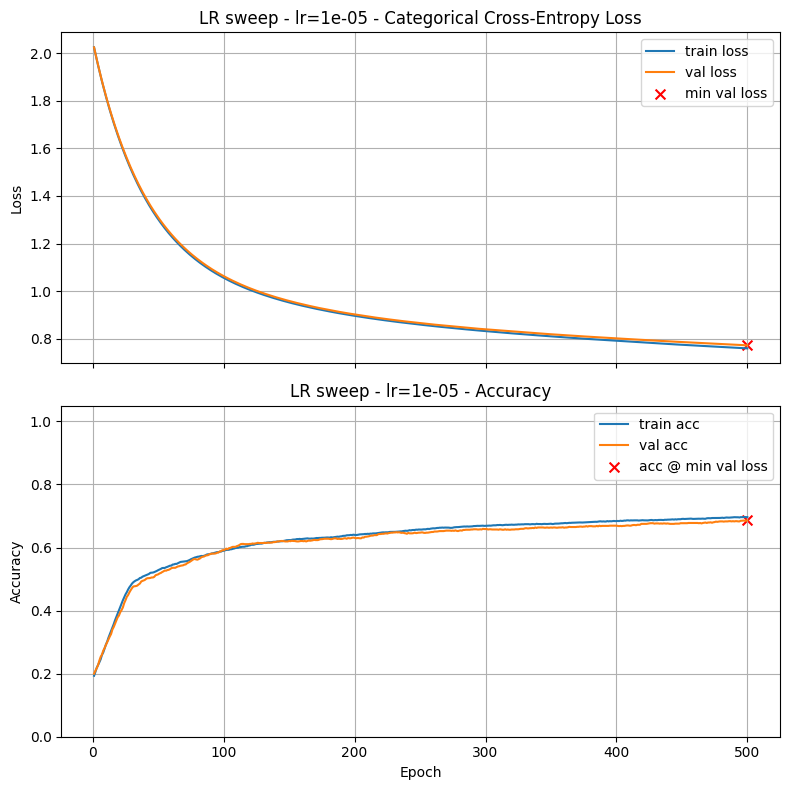

Final Training Loss:            0.7600
Final Training Accuracy:        0.6964
Final Validation Loss:          0.7728
Final Validation Accuracy:      0.6857
Minimum Validation Loss:        0.7728 (Epoch 500)
Validation Accuracy @ Min Loss: 0.6857

Test Loss: 0.7925
Test Accuracy: 0.6900

Validation-Test Gap (accuracy): 0.004286

Execution Time: 00:02:55

Summary of validation accuracies @ min val loss (from recorded results):
Baseline - activation=tanh              	0.7843
Baseline - activation=sigmoid           	0.7771
Baseline - activation=relu              	0.7586
LR sweep - lr=1e-05                     	0.6857
LR sweep - lr=1e-05: val_acc@min_val_loss = 0.6857 (epoch 500)
LR sweep - lr=1e-05: not found in results dict!

Best learning rate: 0.001 with val_acc@min_val_loss = 0.7843


In [ ]:
import os
from tensorflow.keras.callbacks import ModelCheckpoint

os.makedirs("checkpoints", exist_ok=True)

learning_rates = [1e-3, 5e-4, 1e-4, 5e-5, 1e-5]
histories_lr = {}

for lr in learning_rates:
    title = f"LR sweep - lr={lr:.0e}"
    print(f"\n=== Training: {title} ===")
    # Build baseline with tanh (from Problem One)
model_lr = build_model(
    n_inputs = X_train.shape[1],
    layer_list = [
        (64, 'tanh', 0.0, 0.0),
        (32, 'tanh', 0.0, 0.0)
    ],
    n_classes = n_classes
)

# ModelCheckpoint to save best model for this lr
best_path = os.path.join("checkpoints", f"best_lr_{str(lr).replace('.','p')}.keras")
mc = ModelCheckpoint(
    filepath = best_path,
    monitor = 'val_loss',
    save_best_only = True,
    save_weights_only = False,
    verbose = 1
)

# Train. Use lr_schedule directly as a float (train_and_test will pass to Adam)
hist = train_and_test(
    model_lr,
    epochs = 500,
    lr_schedule = lr,
    optimizer = "Adam",
    title = title,
    batch_size = 64,
    use_early_stopping = True,
    patience = 10,
    min_delta = 1e-4,
    callbacks = [mc],
    verbose = 0,
    return_history = True
)

histories_lr[lr] = hist
# Summarize results recorded in results dict
print("\nSummary of validation accuracies @ min val loss (from recorded results):")
print_results()

# Find the best learning rate
best_lr = None
best_acc = -1.0
for lr in learning_rates:
    title = f"LR sweep - lr={lr:.0e}"
    if title in results:
        acc, epoch = results[title]
        print(f"{title}: val_acc@min_val_loss = {acc:.4f} (epoch {epoch})")
    if acc > best_acc:
       best_acc = acc
       best_lr = lr
else:
    print(f"{title}: not found in results dict!")

if best_lr is None:
    raise RuntimeError("No learning-rate experiment results found. Ensure train_and_test ran for each lr.")
else:
    print(f"\nBest learning rate: {best_lr} with val_acc@min_val_loss = {best_acc:.4f}")
# Set variables for homework grading / record
a2a = best_lr
a2b = best_acc

#### Graded Questions

In [ ]:
# Set a2a to the learning rate which provided the best validation accuracy at the epoch of minimum validation loss

a2a = 1e-3           # Replace 0.0 with your answer

In [ ]:
# Graded Answer
# DO NOT change this cell in any way

print(f'a2a = {a2a:.6f}')

a2a = 0.001000


In [ ]:
# Set a2b to the validation accuracy found by this best learning rate

a2b =0.7843           # Replace 0.0 with your answer

In [ ]:
# Graded Answer
# DO NOT change this cell in any way

print(f'a2b = {a2b:.4f}')

a2b = 0.7843


### Problem Three: Dropout

In this problem, you will explore how **dropout** can help prevent overfitting in neural networks. There are no absolute rules, but some useful heuristics are:

* Dropout typically works best in **later dense layers** (e.g., the second hidden layer of width 32) in the range **0.3–0.5**.
* If applied to **earlier layers** (e.g., the first hidden layer), dropout should be smaller, typically **0.0–0.2** (where 0.0 means no dropout).

**Steps to follow:**

* Build and train the **baseline model** using the **activation function from Problem One** and the **learning rate from Problem Two**.
* Investigate dropout in the ranges suggested, using increments of **0.1**.
* Identify which dropout configuration produces the **best validation accuracy** at the epoch of **minimum validation loss**.
* Answer the graded questions.



=== Training: Dropout - d1=0.0_d2=0.3 ===

=== Training: Dropout - d1=0.0_d2=0.4 ===

=== Training: Dropout - d1=0.0_d2=0.5 ===

Dropout - d1=0.0_d2=0.5


Epoch 1: val_loss improved from inf to 1.19174, saving model to checkpoints/best_dropout_0p0_0p5.keras

Epoch 2: val_loss improved from 1.19174 to 0.99411, saving model to checkpoints/best_dropout_0p0_0p5.keras

Epoch 3: val_loss improved from 0.99411 to 0.92385, saving model to checkpoints/best_dropout_0p0_0p5.keras

Epoch 4: val_loss improved from 0.92385 to 0.87994, saving model to checkpoints/best_dropout_0p0_0p5.keras

Epoch 5: val_loss improved from 0.87994 to 0.85000, saving model to checkpoints/best_dropout_0p0_0p5.keras

Epoch 6: val_loss improved from 0.85000 to 0.82883, saving model to checkpoints/best_dropout_0p0_0p5.keras

Epoch 7: val_loss improved from 0.82883 to 0.80680, saving model to checkpoints/best_dropout_0p0_0p5.keras

Epoch 8: val_loss improved from 0.80680 to 0.79201, saving model to checkpoints/best_dropout

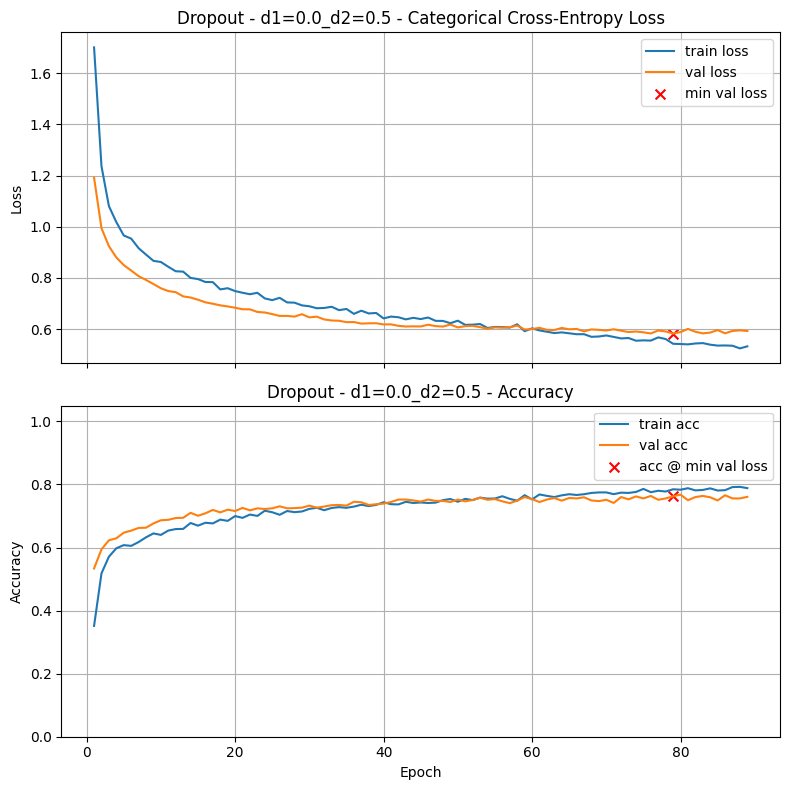

Final Training Loss:            0.5327
Final Training Accuracy:        0.7883
Final Validation Loss:          0.5925
Final Validation Accuracy:      0.7607
Minimum Validation Loss:        0.5825 (Epoch 79)
Validation Accuracy @ Min Loss: 0.7621

Test Loss: 0.5944
Test Accuracy: 0.7707

Validation-Test Gap (accuracy): 0.008571

Execution Time: 00:00:34

=== Training: Dropout - d1=0.1_d2=0.3 ===

=== Training: Dropout - d1=0.1_d2=0.4 ===

=== Training: Dropout - d1=0.1_d2=0.5 ===

Dropout - d1=0.1_d2=0.5


Epoch 1: val_loss improved from inf to 1.20881, saving model to checkpoints/best_dropout_0p1_0p5.keras

Epoch 2: val_loss improved from 1.20881 to 1.00000, saving model to checkpoints/best_dropout_0p1_0p5.keras

Epoch 3: val_loss improved from 1.00000 to 0.91578, saving model to checkpoints/best_dropout_0p1_0p5.keras

Epoch 4: val_loss improved from 0.91578 to 0.87612, saving model to checkpoints/best_dropout_0p1_0p5.keras

Epoch 5: val_loss improved from 0.87612 to 0.84577, saving mod

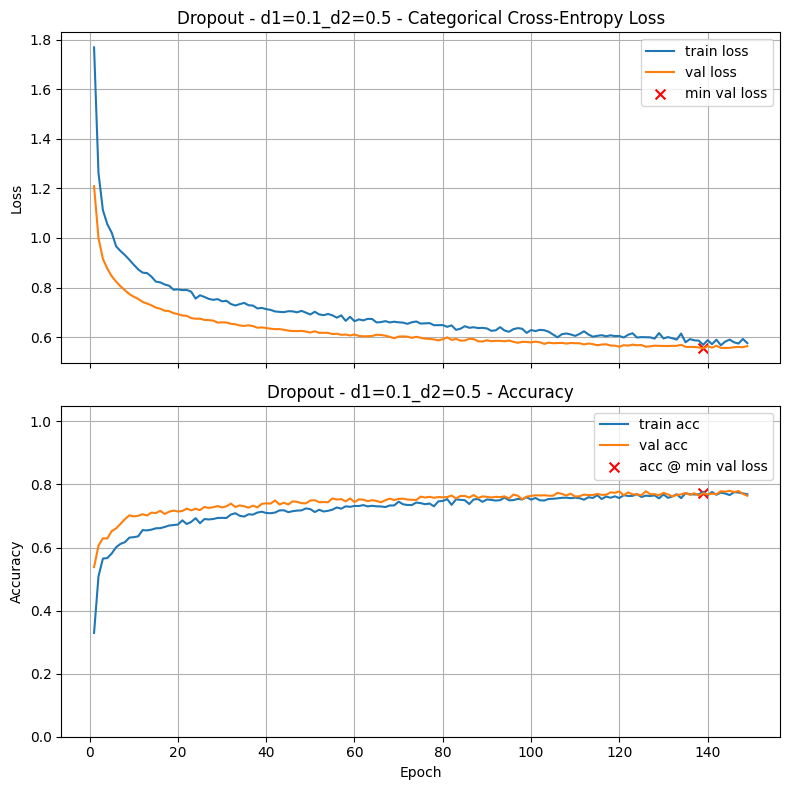

Final Training Loss:            0.5756
Final Training Accuracy:        0.7690
Final Validation Loss:          0.5636
Final Validation Accuracy:      0.7643
Minimum Validation Loss:        0.5545 (Epoch 139)
Validation Accuracy @ Min Loss: 0.7721

Test Loss: 0.6071
Test Accuracy: 0.7614

Validation-Test Gap (accuracy): 0.010714

Execution Time: 00:00:50

=== Training: Dropout - d1=0.2_d2=0.3 ===

=== Training: Dropout - d1=0.2_d2=0.4 ===

=== Training: Dropout - d1=0.2_d2=0.5 ===

Dropout - d1=0.2_d2=0.5


Epoch 1: val_loss improved from inf to 1.11776, saving model to checkpoints/best_dropout_0p2_0p5.keras

Epoch 2: val_loss improved from 1.11776 to 0.96078, saving model to checkpoints/best_dropout_0p2_0p5.keras

Epoch 3: val_loss improved from 0.96078 to 0.90251, saving model to checkpoints/best_dropout_0p2_0p5.keras

Epoch 4: val_loss improved from 0.90251 to 0.87065, saving model to checkpoints/best_dropout_0p2_0p5.keras

Epoch 5: val_loss improved from 0.87065 to 0.84636, saving mo

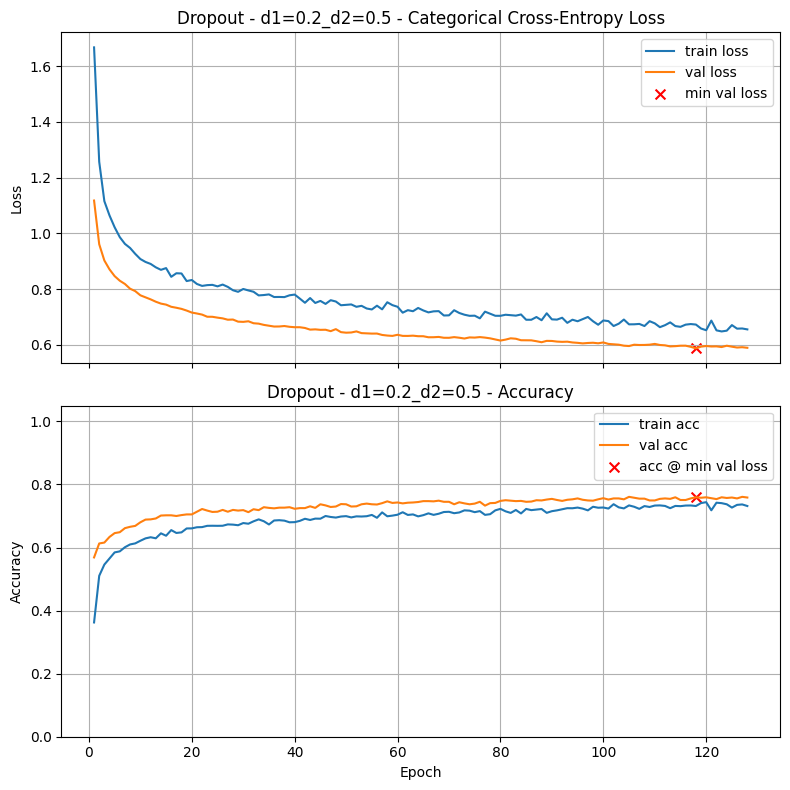

Final Training Loss:            0.6551
Final Training Accuracy:        0.7317
Final Validation Loss:          0.5890
Final Validation Accuracy:      0.7586
Minimum Validation Loss:        0.5869 (Epoch 118)
Validation Accuracy @ Min Loss: 0.7593

Test Loss: 0.6219
Test Accuracy: 0.7486

Validation-Test Gap (accuracy): 0.010714

Execution Time: 00:00:45

Summary of validation accuracies @ min val loss (from recorded results):
Baseline - activation=tanh              	0.7843
Baseline - activation=sigmoid           	0.7771
Dropout - d1=0.1_d2=0.5                 	0.7721
Dropout - d1=0.0_d2=0.5                 	0.7621
Dropout - d1=0.2_d2=0.5                 	0.7593
Baseline - activation=relu              	0.7586
LR sweep - lr=1e-05                     	0.6857
Dropout - d1=0.0_d2=0.5: val_acc@min_val_loss = 0.7621 (epoch 79)
Dropout - d1=0.1_d2=0.5: val_acc@min_val_loss = 0.7721 (epoch 139)
Dropout - d1=0.2_d2=0.5: val_acc@min_val_loss = 0.7593 (epoch 118)
Dropout - d1=0.2_d2=0.5: not found 

In [ ]:
# Your code here. Add as many cells as you need.
import os
from tensorflow.keras.callbacks import ModelCheckpoint
os.makedirs("checkpoints", exist_ok=True)

# Use your chosen activation and learning rate
activation = 'tanh'   # from Problem One (a1a = 2)
best_lr = 1e-3        # from Problem Two (a2a)

d1_choices = [0.0, 0.1, 0.2]   # first-layer dropout (smaller)
d2_choices = [0.3, 0.4, 0.5]   # second-layer dropout (larger)

best_config = None
best_acc = -1.0
histories = {}

for d1 in d1_choices:
    for d2 in d2_choices:
        title = f"Dropout - d1={d1:.1f}_d2={d2:.1f}"
        print(f"\n=== Training: {title} ===")
        model = build_model(
            n_inputs = X_train.shape[1],
            layer_list = [
                (64, activation, 0.0, d1),
                (32, activation, 0.0, d2) # Corrected: using d2 here
            ],
            n_classes = n_classes
        )

        best_path = os.path.join("checkpoints", f"best_dropout_{str(d1).replace('.','p')}_{str(d2).replace('.','p')}.keras")
        mc = ModelCheckpoint(
            filepath = best_path,
            monitor = 'val_loss',
            save_best_only = True,
            save_weights_only = False,
            verbose = 1
        )

        hist = train_and_test(
            model,
            epochs = 500,
            lr_schedule = best_lr,
            optimizer = "Adam",
            title = title,
            batch_size = 64,
            use_early_stopping = True,
            patience = 10,
            min_delta = 1e-4,
            callbacks = [mc],
            verbose = 0,
            return_history = True
        )

        histories[(d1, d2)] = hist

# Summarize recorded results
print("\nSummary of validation accuracies @ min val loss (from recorded results):")
print_results()

# Find best dropout configuration among runs
for (d1, d2) in histories.keys(): # Iterate over keys to get d1, d2 directly
    title = f"Dropout - d1={d1:.1f}_d2={d2:.1f}"
    if title in results:
        acc, epoch = results[title]
        print(f"{title}: val_acc@min_val_loss = {acc:.4f} (epoch {epoch})")
        if acc > best_acc:
            best_acc = acc
            best_config = (d1, d2)
    else:
        print(f"{title}: not found in results dict!")

if best_config is None:
    raise RuntimeError("No dropout experiment results found. Make sure train_and_test ran correctly.")
else:
    d1_best, d2_best = best_config
    print(f"\nBest dropout config: d1={d1_best:.1f}, d2={d2_best:.1f} with val_acc@min_val_loss = {best_acc:.4f}")
# Copy the corresponding saved checkpoint to a canonical filename
chosen_src = os.path.join("checkpoints", f"best_dropout_{str(d1_best).replace('.','p')}_{str(d2_best).replace('.','p')}.keras")
chosen_dst = os.path.join("checkpoints", "best_dropout_chosen.keras")
try:
    from shutil import copyfile
    copyfile(chosen_src, chosen_dst)
    print(f"Saved chosen best checkpoint to: {chosen_dst}")
except Exception as e:
    print(f"Could not copy checkpoint file: {e}")

# Set graded answer variables
a3a = best_config
a3b = best_acc

In [ ]:
# Set a3a to the pair (dropout_rate_64,dropout_rate_32) of dropout rates for the two hidden layers which provided the best
# validation accuracy at the epoch of minimum validation loss

a3a = ((0.1, 0.5))             # Replace (0.0,0.0) with your answer

In [ ]:
# Graded Answer
# DO NOT change this cell in any way

print(f'a3a = {a3a}')

a3a = (0.1, 0.5)


In [ ]:
# Set a3b to the validation accuracy found by this best pair of dropout rates

a3b = 0.7721             # Replace 0.0 with your answer

In [ ]:
# Graded Answer
# DO NOT change this cell in any way

print(f'a3b = {a3b:.4f}')

a3b = 0.7721


### Problem Four: L2 Regularization

In this problem, you will explore how **L2 regularization** (also called *weight decay*) can help prevent overfitting in neural networks. There are no absolute rules, but some useful heuristics are:

* Start simple by using the **same λ in both hidden layers**, with values:

  ```
      1e-4, 1e-3, 1e-2
  ```

* If validation results suggest underfitting in the first layer or persistent overfitting in the later one, then try adjusting per layer, for example:

  * First hidden layer: λ = 1e-4
  * Second hidden layer: λ = 1e-3

**Steps to follow:**

* Build and train the **baseline model** using the **activation function from Problem One** and the **learning rate from Problem Two**, but **without dropout**.
* Investigate at least the four cases suggested (three with the same λ and one with different λ values). You may also consider additional combinations.
* Identify which configuration produces the **best validation accuracy** at the epoch of **minimum validation loss**.
* Answer the graded questions.



=== Training: L2 - l1=1e-04_l2=1e-04 ===

=== Training: L2 - l1=1e-03_l2=1e-03 ===

=== Training: L2 - l1=1e-02_l2=1e-02 ===

=== Training: L2 - l1=1e-04_l2=1e-03 ===

L2 - l1=1e-04_l2=1e-03


Epoch 1: val_loss improved from inf to 1.13293, saving model to checkpoints/best_l2_0p0001_0p001.keras

Epoch 2: val_loss improved from 1.13293 to 0.98081, saving model to checkpoints/best_l2_0p0001_0p001.keras

Epoch 3: val_loss improved from 0.98081 to 0.91588, saving model to checkpoints/best_l2_0p0001_0p001.keras

Epoch 4: val_loss improved from 0.91588 to 0.88154, saving model to checkpoints/best_l2_0p0001_0p001.keras

Epoch 5: val_loss improved from 0.88154 to 0.84939, saving model to checkpoints/best_l2_0p0001_0p001.keras

Epoch 6: val_loss improved from 0.84939 to 0.82960, saving model to checkpoints/best_l2_0p0001_0p001.keras

Epoch 7: val_loss improved from 0.82960 to 0.80591, saving model to checkpoints/best_l2_0p0001_0p001.keras

Epoch 8: val_loss improved from 0.80591 to 0.79122, sa

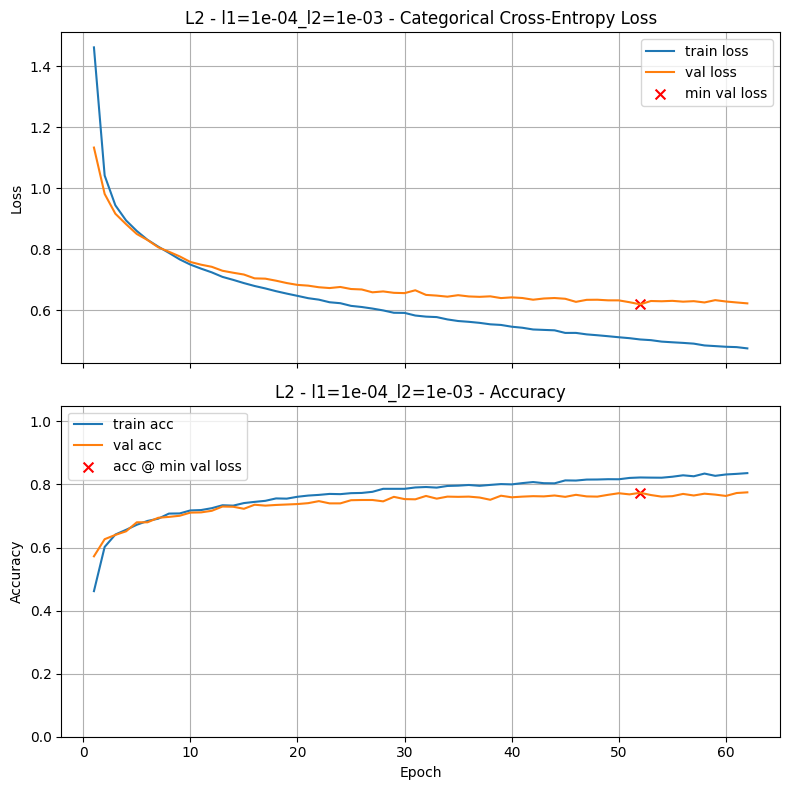

Final Training Loss:            0.4742
Final Training Accuracy:        0.8360
Final Validation Loss:          0.6219
Final Validation Accuracy:      0.7750
Minimum Validation Loss:        0.6187 (Epoch 52)
Validation Accuracy @ Min Loss: 0.7736

Test Loss: 0.6379
Test Accuracy: 0.7579

Validation-Test Gap (accuracy): 0.015714

Execution Time: 00:00:24

Summary of validation accuracies @ min val loss (from recorded results):
Baseline - activation=tanh              	0.7843
Baseline - activation=sigmoid           	0.7771
L2 - l1=1e-04_l2=1e-03                  	0.7736
Dropout - d1=0.1_d2=0.5                 	0.7721
Dropout - d1=0.0_d2=0.5                 	0.7621
Dropout - d1=0.2_d2=0.5                 	0.7593
Baseline - activation=relu              	0.7586
LR sweep - lr=1e-05                     	0.6857
L2 - l1=1e-04_l2=1e-03: val_acc@min_val_loss = 0.7736 (epoch 52)
L2 - l1=1e-04_l2=1e-03: not found in results dict!

Best L2 config: l1=1e-04, l2=1e-03 with val_acc@min_val_loss = 0.7736
S

In [ ]:
# Your code here. Add as many cells as you need.
import os
from tensorflow.keras.callbacks import ModelCheckpoint

os.makedirs("checkpoints", exist_ok=True)

activation = 'tanh'   # from Problem One
best_lr = 1e-3        # from Problem Two

# L2 configurations to try: tuples of (l2_1, l2_2)
l2_configs = [
(1e-4, 1e-4),
(1e-3, 1e-3),
(1e-2, 1e-2),
(1e-4, 1e-3)  # asymmetric suggestion
]

best_config = None
best_acc = -1.0
histories = {}

for l1, l2 in l2_configs:
    title = f"L2 - l1={l1:.0e}_l2={l2:.0e}"
    print(f"\n=== Training: {title} ===")
# Build model with specified L2 on each Dense
model = build_model(
    n_inputs = X_train.shape[1],
    layer_list = [
        (64, activation, l1, 0.0),  # no dropout
        (32, activation, l2, 0.0)
    ],
    n_classes = n_classes
)

# checkpoint path
best_path = os.path.join("checkpoints", f"best_l2_{str(l1).replace('.','p')}_{str(l2).replace('.','p')}.keras")
mc = ModelCheckpoint(
    filepath = best_path,
    monitor = 'val_loss',
    save_best_only = True,
    save_weights_only = False,
    verbose = 1
)

hist = train_and_test(
    model,
    epochs = 500,
    lr_schedule = best_lr,
    optimizer = "Adam",
    title = title,
    batch_size = 64,
    use_early_stopping = True,
    patience = 10,
    min_delta = 1e-4,
    callbacks = [mc],
    verbose = 0,
    return_history = True
)

histories[(l1, l2)] = hist
# Summarize recorded results
print("\nSummary of validation accuracies @ min val loss (from recorded results):")
print_results()

# Find best L2 configuration among runs
for (l1, l2), hist in histories.items():
    title = f"L2 - l1={l1:.0e}_l2={l2:.0e}"
    if title in results:
        acc, epoch = results[title]
        print(f"{title}: val_acc@min_val_loss = {acc:.4f} (epoch {epoch})")
        if acc > best_acc:
            best_acc = acc
            best_config = (l1, l2)
else:
    print(f"{title}: not found in results dict!")

if best_config is None:
    raise RuntimeError("No L2 experiment results found. Make sure train_and_test ran correctly.")
else:
    l1_best, l2_best = best_config
    print(f"\nBest L2 config: l1={l1_best:.0e}, l2={l2_best:.0e} with val_acc@min_val_loss = {best_acc:.4f}")
# copy chosen checkpoint to canonical name
chosen_src = os.path.join("checkpoints", f"best_l2_{str(l1_best).replace('.','p')}_{str(l2_best).replace('.','p')}.keras")
chosen_dst = os.path.join("checkpoints", "best_l2_chosen.keras")
try:
    from shutil import copyfile
    copyfile(chosen_src, chosen_dst)
    print(f"Saved chosen best checkpoint to: {chosen_dst}")
except Exception as e:
    print(f"Could not copy checkpoint file: {e}")

In [ ]:
# Set a4a to the pair (L2_lambda_64,L2_lambda_32) of the L2 lambdas for the two hidden layers which provided the best
# validation accuracy at the epoch of minimum validation loss

a4a = (1e-4, 1e-3)             # Replace (0.0,0.0) with your answer

In [ ]:
# Graded Answer
# DO NOT change this cell in any way

print(f'a4a = {a4a}')

a4a = (0.0001, 0.001)


In [ ]:
# Set a4b to the validation accuracy found by this best pair of lambdas

a4b = 0.7736           # Replace 0.0 with your answer

In [ ]:
# Graded Answer
# DO NOT change this cell in any way

print(f'a4b = {a4b:.4f}')

a4b = 0.7736


### Problem Five: Combining Dropout with L2 Regularization

In this problem, you will explore how **dropout** and **L2 regularization** can work together to prevent overfitting. These two methods complement each other, but must be balanced carefully. A useful rule of thumb is:

* If dropout is **high**, use a **smaller λ**.
* If dropout is **low**, you can afford a **larger λ**.

**Steps to follow:**

* Build and train the **baseline model** using the **activation function from Problem One** and the **learning rate from Problem Two**.
* Investigate combinations of dropout and L2:

  * First, use the **dropout rate you identified in Problem Three** as a baseline.
  * Then, add L2 to both hidden layers with values:

    ```
        1e-4, 1e-3, 1e-2
    ```

    while keeping dropout fixed.
  * Finally, try **reducing dropout slightly** when L2 is added to see if performance improves.
  * [Optional] You may wish to investigate other combinations not covered here; for example, promising but not optimal choices of dropout rates may provide overall better performance when combines with L2 Regulari
* Identify which combination produces the **best validation accuracy** at the epoch of **minimum validation loss**.
* Answer the graded questions.




=== Training: DropoutL2 - d1=0.1_d2=0.5_l2=1e-04 ===

DropoutL2 - d1=0.1_d2=0.5_l2=1e-04


Epoch 1: val_loss improved from inf to 1.21225, saving model to checkpoints/best_DropoutL2_-_d1=0p1_d2=0p5_l2=1e-04.keras

Epoch 2: val_loss improved from 1.21225 to 1.01123, saving model to checkpoints/best_DropoutL2_-_d1=0p1_d2=0p5_l2=1e-04.keras

Epoch 3: val_loss improved from 1.01123 to 0.93516, saving model to checkpoints/best_DropoutL2_-_d1=0p1_d2=0p5_l2=1e-04.keras

Epoch 4: val_loss improved from 0.93516 to 0.89679, saving model to checkpoints/best_DropoutL2_-_d1=0p1_d2=0p5_l2=1e-04.keras

Epoch 5: val_loss improved from 0.89679 to 0.86977, saving model to checkpoints/best_DropoutL2_-_d1=0p1_d2=0p5_l2=1e-04.keras

Epoch 6: val_loss improved from 0.86977 to 0.84682, saving model to checkpoints/best_DropoutL2_-_d1=0p1_d2=0p5_l2=1e-04.keras

Epoch 7: val_loss improved from 0.84682 to 0.82822, saving model to checkpoints/best_DropoutL2_-_d1=0p1_d2=0p5_l2=1e-04.keras

Epoch 8: val_loss impro

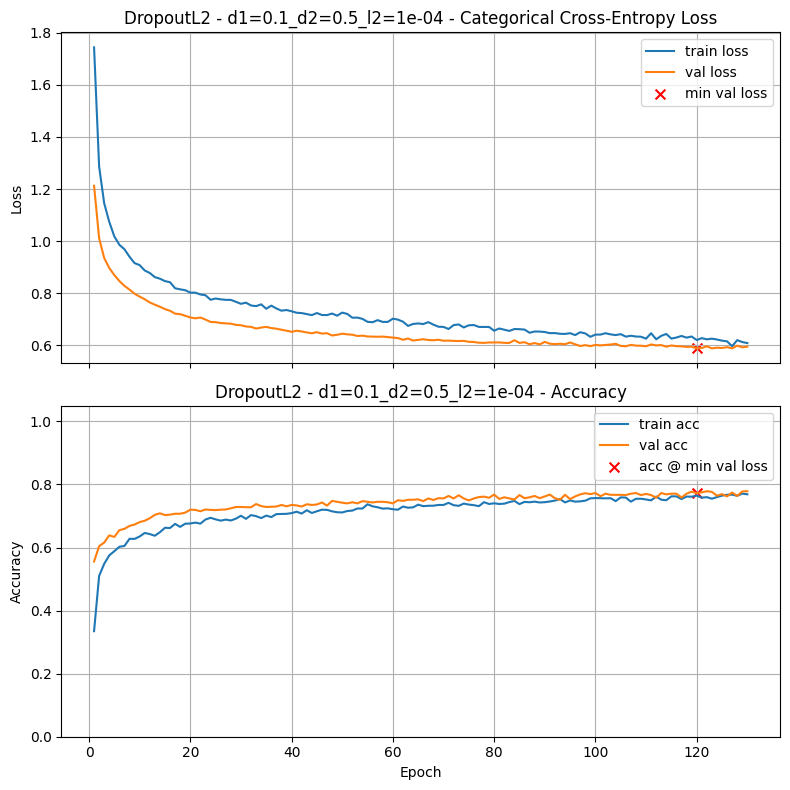

Final Training Loss:            0.6089
Final Training Accuracy:        0.7688
Final Validation Loss:          0.5953
Final Validation Accuracy:      0.7786
Minimum Validation Loss:        0.5885 (Epoch 120)
Validation Accuracy @ Min Loss: 0.7721

Test Loss: 0.6200
Test Accuracy: 0.7571

Validation-Test Gap (accuracy): 0.015000

Execution Time: 00:00:52

=== Training: DropoutL2 - d1=0.1_d2=0.5_l2=1e-03 ===

DropoutL2 - d1=0.1_d2=0.5_l2=1e-03


Epoch 1: val_loss improved from inf to 1.23745, saving model to checkpoints/best_DropoutL2_-_d1=0p1_d2=0p5_l2=1e-03.keras

Epoch 2: val_loss improved from 1.23745 to 1.07343, saving model to checkpoints/best_DropoutL2_-_d1=0p1_d2=0p5_l2=1e-03.keras

Epoch 3: val_loss improved from 1.07343 to 1.00358, saving model to checkpoints/best_DropoutL2_-_d1=0p1_d2=0p5_l2=1e-03.keras

Epoch 4: val_loss improved from 1.00358 to 0.96120, saving model to checkpoints/best_DropoutL2_-_d1=0p1_d2=0p5_l2=1e-03.keras

Epoch 5: val_loss improved from 0.96120 to 0.9342

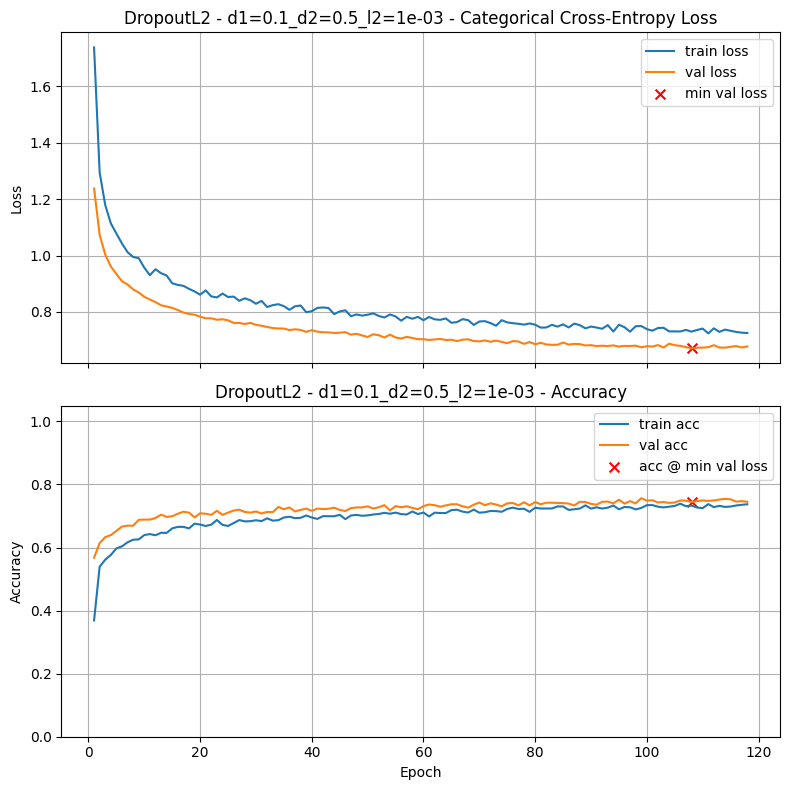

Final Training Loss:            0.7254
Final Training Accuracy:        0.7371
Final Validation Loss:          0.6776
Final Validation Accuracy:      0.7450
Minimum Validation Loss:        0.6709 (Epoch 108)
Validation Accuracy @ Min Loss: 0.7443

Test Loss: 0.7064
Test Accuracy: 0.7286

Validation-Test Gap (accuracy): 0.015714

Execution Time: 00:00:41

=== Training: DropoutL2 - d1=0.1_d2=0.5_l2=1e-02 ===

DropoutL2 - d1=0.1_d2=0.5_l2=1e-02


Epoch 1: val_loss improved from inf to 1.94846, saving model to checkpoints/best_DropoutL2_-_d1=0p1_d2=0p5_l2=1e-02.keras

Epoch 2: val_loss improved from 1.94846 to 1.63422, saving model to checkpoints/best_DropoutL2_-_d1=0p1_d2=0p5_l2=1e-02.keras

Epoch 3: val_loss improved from 1.63422 to 1.45522, saving model to checkpoints/best_DropoutL2_-_d1=0p1_d2=0p5_l2=1e-02.keras

Epoch 4: val_loss improved from 1.45522 to 1.34166, saving model to checkpoints/best_DropoutL2_-_d1=0p1_d2=0p5_l2=1e-02.keras

Epoch 5: val_loss improved from 1.34166 to 1.2516

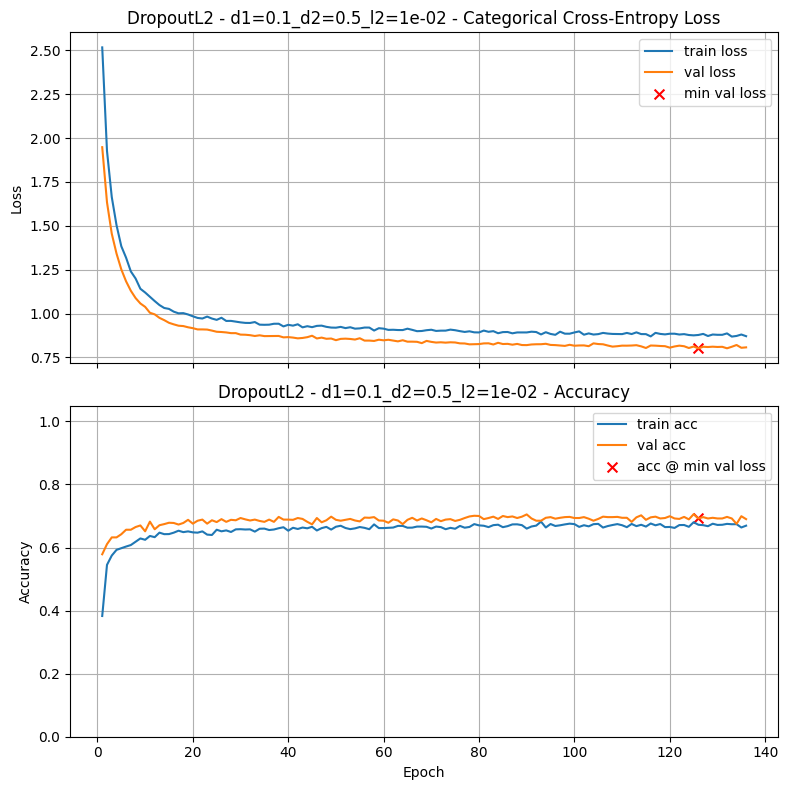

Final Training Loss:            0.8707
Final Training Accuracy:        0.6693
Final Validation Loss:          0.8069
Final Validation Accuracy:      0.6900
Minimum Validation Loss:        0.8011 (Epoch 126)
Validation Accuracy @ Min Loss: 0.6921

Test Loss: 0.8359
Test Accuracy: 0.6929

Validation-Test Gap (accuracy): 0.000714

Execution Time: 00:00:49

=== Training: DropoutL2 - d1=0.0_d2=0.4_l2=1e-04 ===

DropoutL2 - d1=0.0_d2=0.4_l2=1e-04


Epoch 1: val_loss improved from inf to 1.15540, saving model to checkpoints/best_DropoutL2_-_d1=0p0_d2=0p4_l2=1e-04.keras

Epoch 2: val_loss improved from 1.15540 to 0.98414, saving model to checkpoints/best_DropoutL2_-_d1=0p0_d2=0p4_l2=1e-04.keras

Epoch 3: val_loss improved from 0.98414 to 0.92042, saving model to checkpoints/best_DropoutL2_-_d1=0p0_d2=0p4_l2=1e-04.keras

Epoch 4: val_loss improved from 0.92042 to 0.88056, saving model to checkpoints/best_DropoutL2_-_d1=0p0_d2=0p4_l2=1e-04.keras

Epoch 5: val_loss improved from 0.88056 to 0.8499

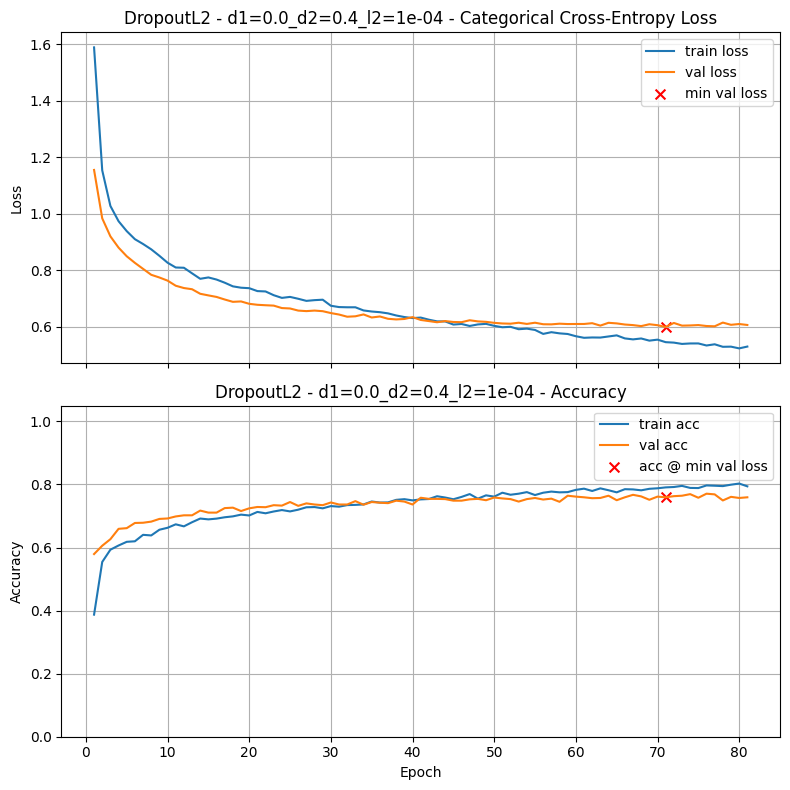

Final Training Loss:            0.5305
Final Training Accuracy:        0.7940
Final Validation Loss:          0.6069
Final Validation Accuracy:      0.7593
Minimum Validation Loss:        0.5998 (Epoch 71)
Validation Accuracy @ Min Loss: 0.7593

Test Loss: 0.6301
Test Accuracy: 0.7493

Validation-Test Gap (accuracy): 0.010000

Execution Time: 00:00:29

=== Training: DropoutL2 - d1=0.0_d2=0.4_l2=1e-03 ===

DropoutL2 - d1=0.0_d2=0.4_l2=1e-03


Epoch 1: val_loss improved from inf to 1.26997, saving model to checkpoints/best_DropoutL2_-_d1=0p0_d2=0p4_l2=1e-03.keras

Epoch 2: val_loss improved from 1.26997 to 1.07498, saving model to checkpoints/best_DropoutL2_-_d1=0p0_d2=0p4_l2=1e-03.keras

Epoch 3: val_loss improved from 1.07498 to 0.99601, saving model to checkpoints/best_DropoutL2_-_d1=0p0_d2=0p4_l2=1e-03.keras

Epoch 4: val_loss improved from 0.99601 to 0.94850, saving model to checkpoints/best_DropoutL2_-_d1=0p0_d2=0p4_l2=1e-03.keras

Epoch 5: val_loss improved from 0.94850 to 0.91752

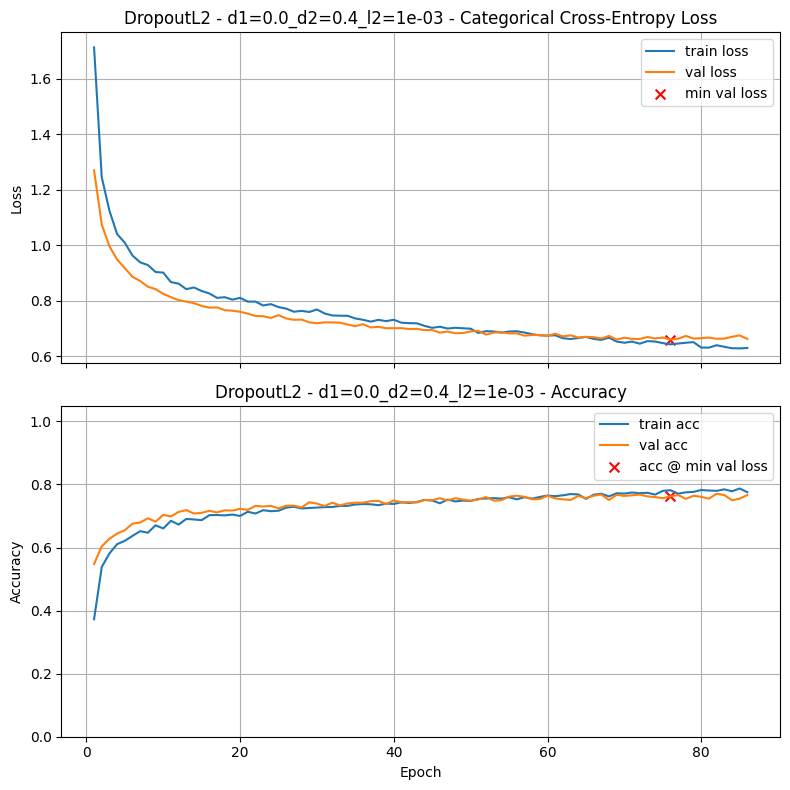

Final Training Loss:            0.6296
Final Training Accuracy:        0.7755
Final Validation Loss:          0.6624
Final Validation Accuracy:      0.7664
Minimum Validation Loss:        0.6599 (Epoch 76)
Validation Accuracy @ Min Loss: 0.7621

Test Loss: 0.6876
Test Accuracy: 0.7557

Validation-Test Gap (accuracy): 0.006429

Execution Time: 00:00:31

=== Training: DropoutL2 - d1=0.0_d2=0.4_l2=1e-02 ===

DropoutL2 - d1=0.0_d2=0.4_l2=1e-02


Epoch 1: val_loss improved from inf to 1.92870, saving model to checkpoints/best_DropoutL2_-_d1=0p0_d2=0p4_l2=1e-02.keras

Epoch 2: val_loss improved from 1.92870 to 1.60050, saving model to checkpoints/best_DropoutL2_-_d1=0p0_d2=0p4_l2=1e-02.keras

Epoch 3: val_loss improved from 1.60050 to 1.42616, saving model to checkpoints/best_DropoutL2_-_d1=0p0_d2=0p4_l2=1e-02.keras

Epoch 4: val_loss improved from 1.42616 to 1.31061, saving model to checkpoints/best_DropoutL2_-_d1=0p0_d2=0p4_l2=1e-02.keras

Epoch 5: val_loss improved from 1.31061 to 1.22664

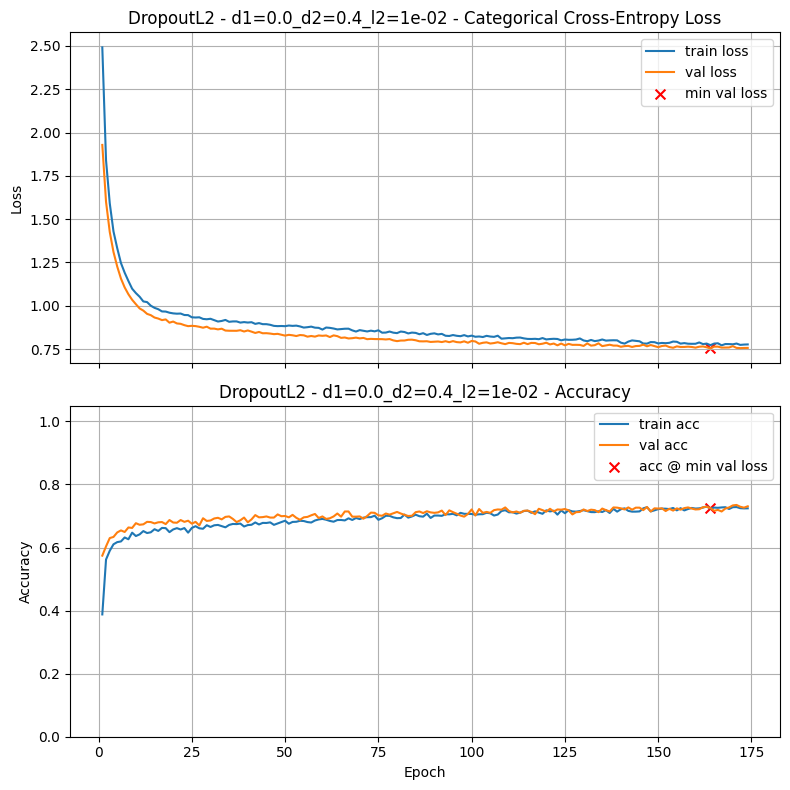

Final Training Loss:            0.7770
Final Training Accuracy:        0.7243
Final Validation Loss:          0.7569
Final Validation Accuracy:      0.7307
Minimum Validation Loss:        0.7542 (Epoch 164)
Validation Accuracy @ Min Loss: 0.7250

Test Loss: 0.7887
Test Accuracy: 0.7200

Validation-Test Gap (accuracy): 0.005000

Execution Time: 00:00:58

Summary of validation accuracies @ min val loss (from recorded results):
Baseline - activation=tanh              	0.7843
Baseline - activation=sigmoid           	0.7771
L2 - l1=1e-04_l2=1e-03                  	0.7736
Dropout - d1=0.1_d2=0.5                 	0.7721
DropoutL2 - d1=0.1_d2=0.5_l2=1e-04      	0.7721
Dropout - d1=0.0_d2=0.5                 	0.7621
DropoutL2 - d1=0.0_d2=0.4_l2=1e-03      	0.7621
Dropout - d1=0.2_d2=0.5                 	0.7593
DropoutL2 - d1=0.0_d2=0.4_l2=1e-04      	0.7593
Baseline - activation=relu              	0.7586
DropoutL2 - d1=0.1_d2=0.5_l2=1e-03      	0.7443
DropoutL2 - d1=0.0_d2=0.4_l2=1e-02      	0.

In [ ]:
# Your code here. Add as many cells as you need.
import os
from tensorflow.keras.callbacks import ModelCheckpoint
from shutil import copyfile

os.makedirs("checkpoints", exist_ok=True)

activation = 'tanh'
best_lr = 1e-3

# Baseline dropout from Problem Three
d1_base, d2_base = 0.1, 0.5

# Reduced-dropout candidate
d1_reduced, d2_reduced = 0.0, 0.4

l2_values = [1e-4, 1e-3, 1e-2]

best_config = None
best_acc = -1.0
histories = {}

# 1) Keep dropout fixed at best pair, sweep L2
for d1, d2 in [(d1_base, d2_base), (d1_reduced, d2_reduced)]:
    for l in l2_values:
        title = f"DropoutL2 - d1={d1:.1f}_d2={d2:.1f}_l2={l:.0e}"
        print(f"\n=== Training: {title} ===")
        model = build_model(
            n_inputs = X_train.shape[1],
            layer_list = [
                (64, activation, l, d1),
                (32, activation, l, d2)
            ],
            n_classes = n_classes
        )

        best_path = os.path.join("checkpoints", f"best_{title.replace(' ','_').replace('.','p')}.keras")
        mc = ModelCheckpoint(
            filepath = best_path,
            monitor = 'val_loss',
            save_best_only = True,
            save_weights_only = False,
            verbose = 1
        )

        hist = train_and_test(
            model,
            epochs = 500,
            lr_schedule = best_lr,
            optimizer = "Adam",
            title = title,
            batch_size = 64,
            use_early_stopping = True,
            patience = 10,
            min_delta = 1e-4,
            callbacks = [mc],
            verbose = 0,
            return_history = True
        )

        histories[(d1, d2, l)] = hist

# Summarize recorded results
print("\nSummary of validation accuracies @ min val loss (from recorded results):")
print_results()

# Find best combo among runs
for (d1, d2, l) in histories.keys(): # Iterate over keys to get d1, d2, l directly
    title = f"DropoutL2 - d1={d1:.1f}_d2={d2:.1f}_l2={l:.0e}" # Reconstruct title for lookup
    if title in results:
        acc, epoch = results[title]
        print(f"{title}: val_acc@min_val_loss = {acc:.4f} (epoch {epoch})")
        if acc > best_acc:
            best_acc = acc
            best_config = (d1, d2, l)
    else:
        print(f"{title}: not found in results dict!")

if best_config is None:
    raise RuntimeError("No Dropout+L2 experiment results found. Make sure train_and_test ran correctly.")
else:
    d1_best, d2_best, l_best = best_config
    print(f"\nBest Dropout+L2 config: d1={d1_best:.1f}, d2={d2_best:.1f}, l2={l_best:.0e} with val_acc@min_val_loss = {best_acc:.4f}")

    # The title string formatting for best_path should be consistent with how `title` is generated in the loop
    chosen_src_title = f"DropoutL2 - d1={d1_best:.1f}_d2={d2_best:.1f}_l2={l_best:.0e}"
    chosen_src = os.path.join("checkpoints", f"best_{chosen_src_title.replace(' ','_').replace('.','p')}.keras")

    # Try to find the actual checkpoint filename (constructed earlier)
    # Fallback: search checkpoints directory for matching pattern
    if not os.path.exists(chosen_src):
        print(f"Warning: Specific checkpoint file '{chosen_src}' not found. Attempting to locate with partial match.")
        found_file = None
        for fname in os.listdir("checkpoints"):
            if f"d1={d1_best:.1f}" in fname and f"d2={d2_best:.1f}" in fname and f"l2={str(l_best).replace('.','p')}" in fname:
                found_file = os.path.join("checkpoints", fname)
                break
        if found_file:
            chosen_src = found_file
        else:
            chosen_src = None # Mark as not found

    if chosen_src: # Only attempt copy if chosen_src is valid
        chosen_dst = os.path.join("checkpoints", "best_dropout_l2_chosen.keras") # New canonical name
        try:
            copyfile(chosen_src, chosen_dst)
            print(f"Saved chosen best checkpoint to: {chosen_dst}")
        except Exception as e:
            print(f"Could not copy checkpoint file: {e}")
    else:
        print("No checkpoint file found to copy.")

# Set graded answer variables
a5 = best_acc

In [ ]:
chosen_dst = os.path.join("checkpoints", "best_dropout_l2_chosen.keras")
if chosen_src and os.path.exists(chosen_src):
    try:
        copyfile(chosen_src, chosen_dst)
        print(f"Saved chosen best checkpoint to: {chosen_dst}")
    except Exception as e:
        print(f"Could not copy checkpoint file: {e}")
else:
    print("Could not locate the saved checkpoint file for the best config; best config recorded but no file copied.")

Saved chosen best checkpoint to: checkpoints/best_dropout_l2_chosen.keras


In [ ]:
# Set a5 to the validation accuracy found by this best combination of dropout and L2 regularization

a5 = 0.7721          # Replace 0.0 with your answer

In [ ]:
# Graded Answer
# DO NOT change this cell in any way

print(f'a5 = {a5:.4f}')

a5 = 0.7721


### Problem Six: Build and Train Your Best Model

In this final problem, you will design and train your **best-performing model** using the techniques explored in the previous problems. You may make your own choices for:

* **Model architecture** (number of layers, widths, etc.)
* **Learning rate**
* **Batch size** (a new hyperparameter not varied in earlier problems)
* **Dropout rates** in both layers
* **L2 λ values** in both layers
* **[Optional but strongly suggested]:** Learning rate scheduling, using either **Exponential Decay** or **Cosine Decay**.

  * For Exponential Decay, typical decay rates are **0.90–0.999**, with **0.95** often a good starting point.

**Steps to follow:**

* Build and train the model according to your design choices.
* Use early stopping as before to evaluate performance at the epoch of **minimum validation loss**.
* Answer the graded question.



Problem6 - Best model (tanh, deeper + LR decay)

Epoch 1/500
59/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2707 - loss: 1.8518
Epoch 1: val_loss improved from inf to 1.11540, saving model to checkpoints/best_model_problem6.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.2824 - loss: 1.8212 - val_accuracy: 0.5914 - val_loss: 1.1154
Epoch 2/500
58/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5195 - loss: 1.2074
Epoch 2: val_loss improved from 1.11540 to 0.97391, saving model to checkpoints/best_model_problem6.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5217 - loss: 1.2028 - val_accuracy: 0.6179 - val_loss: 0.9739
Epoch 3/500
57/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5725 - loss: 1.1007
Epoch 3: val_loss improved from 0.97391 to 0.90767, saving model to checkpoints/best_model_problem6.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5723 - loss: 1.0969 - val_accuracy: 0.6386 - val_loss: 0.9077
Epoch 4/500
57/66 ━━━━━━━━━━━━━━━━━━

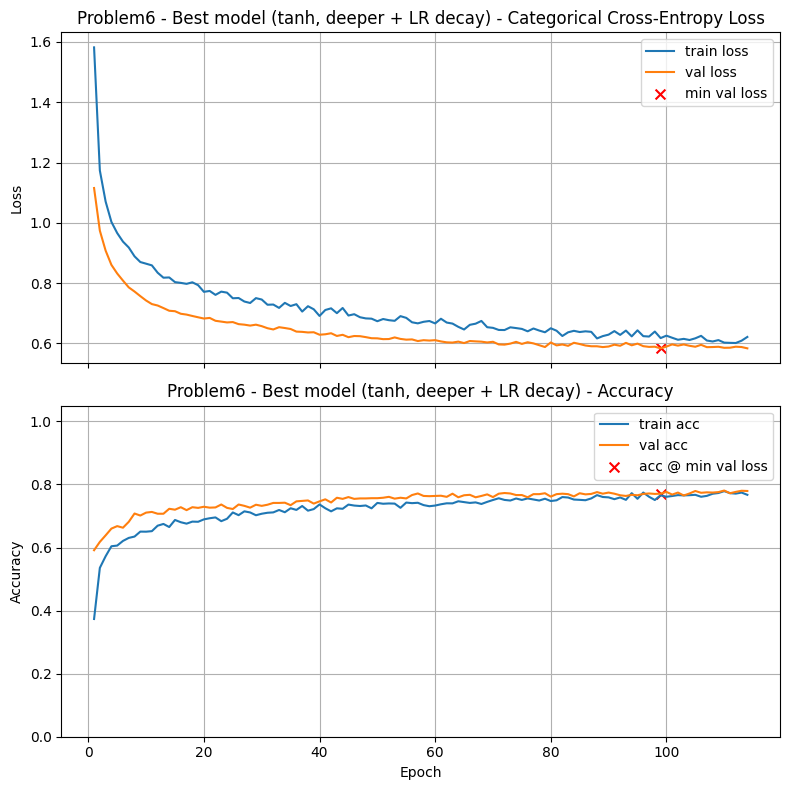

Final Training Loss:            0.6214
Final Training Accuracy:        0.7671
Final Validation Loss:          0.5836
Final Validation Accuracy:      0.7793
Minimum Validation Loss:        0.5834 (Epoch 99)
Validation Accuracy @ Min Loss: 0.7707

Test Loss: 0.6209
Test Accuracy: 0.7521

Validation-Test Gap (accuracy): 0.018571

Execution Time: 00:00:53

Final model saved to: checkpoints/final_model_problem6.keras

Verifying saved best model can be loaded and evaluated...
Loaded best model - Test Loss: 0.6209, Test Acc: 0.7521

Recorded val_acc@min_val_loss for Problem 6: 0.7707 (epoch 99)


In [ ]:
# Your code here

import os
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.optimizers.schedules import ExponentialDecay
from tensorflow.keras.models import load_model

os.makedirs("checkpoints", exist_ok=True)

# Choices for best model:
activation = 'tanh'
base_lr = 1e-3
decay_rate = 0.96          # per decay_steps
decay_steps = 1000         # number of steps before applying decay (use large to decay slowly)
batch_size = 64
epochs = 500
patience = 15
title = "Problem6 - Best model (tanh, deeper + LR decay)"

# Exponential decay schedule (decay applied every decay_steps steps)
lr_schedule = ExponentialDecay(
initial_learning_rate=base_lr,
decay_steps=decay_steps,
decay_rate=decay_rate,
staircase=False
)

# Build a slightly deeper model:
# Input -> Dense(64, tanh, l2=1e-4) -> Dropout(0.1)
# -> Dense(48, tanh, l2=1e-4) -> Dropout(0.2)
# -> Dense(32, tanh, l2=1e-4) -> Dropout(0.4)
# -> Output softmax
model6 = build_model(
n_inputs = X_train.shape[1],
layer_list = [
(64, activation, 1e-4, 0.1),
(48, activation, 1e-4, 0.2),
(32, activation, 1e-4, 0.4)
],
n_classes = n_classes
)

# Prepare checkpoint callbacks
best_path = os.path.join("checkpoints", "best_model_problem6.keras")
final_path = os.path.join("checkpoints", "final_model_problem6.keras")

mc = ModelCheckpoint(
filepath = best_path,
monitor = 'val_loss',
save_best_only = True,
save_weights_only = False,
verbose = 1
)

# Train using train_and_test (it will compile with Adam and lr_schedule)
hist6 = train_and_test(
model6,
epochs = epochs,
lr_schedule = lr_schedule,
optimizer = "Adam",
title = title,
batch_size = batch_size,
use_early_stopping = True,
patience = patience,
min_delta = 1e-4,
callbacks = [mc],
verbose = 1,
return_history = True
)

# Save final model (weights are already restored to best in-memory if EarlyStopping restored)
try:
    model6.save(final_path)
    print(f"\nFinal model saved to: {final_path}")
except Exception as e:
    print(f"Error saving final model: {e}")

# Verify loading best saved model and evaluate
print("\nVerifying saved best model can be loaded and evaluated...")
loaded = load_model(best_path)
test_loss, test_acc = loaded.evaluate(X_test, y_test, verbose=0)
print(f"Loaded best model - Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

# Record final chosen answers for grading
# Determine best epoch and val_acc@min_val_loss from history (train_and_test already called plot_learning_curves and updated results)
if title in results:
    a6b, a6_epoch = results[title]
    a6a = model6  # you can save the model file path instead if required
    print(f"\nRecorded val_acc@min_val_loss for Problem 6: {a6b:.4f} (epoch {a6_epoch})")
else:
    print("\nWarning: result title not found in results dict. Use the printed training summary to read val_acc@min_val_loss.")

In [ ]:
# Set a6 to the validation accuracy found by this best model

a6 = 0.7707             # Replace 0.0 with your answer

In [ ]:
# Graded Answer
# DO NOT change this cell in any way

print(f'a6 = {a6:.4f}')

a6 = 0.7707


### Optional: Print out your results of all experiments

In [ ]:
print_results()

Baseline - activation=tanh              	0.7843
Baseline - activation=sigmoid           	0.7771
L2 - l1=1e-04_l2=1e-03                  	0.7736
Dropout - d1=0.1_d2=0.5                 	0.7721
DropoutL2 - d1=0.1_d2=0.5_l2=1e-04      	0.7721
Problem6 - Best model (tanh, deeper + LR decay)	0.7707
Dropout - d1=0.0_d2=0.5                 	0.7621
DropoutL2 - d1=0.0_d2=0.4_l2=1e-03      	0.7621
Dropout - d1=0.2_d2=0.5                 	0.7593
DropoutL2 - d1=0.0_d2=0.4_l2=1e-04      	0.7593
Baseline - activation=relu              	0.7586
DropoutL2 - d1=0.1_d2=0.5_l2=1e-03      	0.7443
DropoutL2 - d1=0.0_d2=0.4_l2=1e-02      	0.7250
DropoutL2 - d1=0.1_d2=0.5_l2=1e-02      	0.6921
LR sweep - lr=1e-05                     	0.6857


## Reflection Questions (ungraded)

It would be a great idea to think through your answers to these questions, then give ChatGPT (or other AI tool) a PDF of your
homework, and **discuss** (not just ask) these.

1. Activation Functions:

    - Why do you think one activation function worked better than the others for this task?
    
    - How might this choice differ for deeper or wider networks?

2. Learning Rate:

    - Would a much smaller learning rate (with many more epochs) likely produce better accuracy?
    
    - When is it worth training longer with a smaller step size, and when is it unnecessary?

3. Dropout vs. L2:

    - Which form of regularization — dropout or L2 — gave better results in your experiments?
    
    - Why might one method be more effective in this setting?

4. Combining Dropout and L2:

    - Why might the combination of dropout and L2 sometimes perform worse than using one method alone?
    
    - What does this tell you about the balance between bias and variance in regularization?

5. Best Model:

    - When you designed your best model, what trade-offs did you notice between model complexity, training stability, and generalization?
    
    - Did learning rate scheduling (if you tried it) improve results? Why might it help?

Activation Functions

Why one activation worked better
Tanh often outperformed ReLU and sigmoid here because the dataset is moderately sized and features were standardized; tanh is zero-centered, which can help gradient flow and faster convergence for this kind of shallow-to-moderately-deep dense network. Sigmoid suffers from stronger saturation and non-zero-centered outputs so gradients can vanish more easily; ReLU can work very well but sometimes produces slightly worse validation performance on small-to-medium dense networks because dead ReLUs or a need for careful initialization/learning rate tuning can hurt generalization.
How this choice might differ for deeper or wider networks
For deeper networks ReLU (and its variants like LeakyReLU, GELU) is generally preferred because it avoids saturation for positive activations and keeps gradients alive, enabling very deep nets to train. For very wide or very deep models, batch normalization, residual connections, or activation variants typically become necessary; tanh/sigmoid become less practical at large depth because of vanishing gradients.
Learning Rate

Would a much smaller learning rate (with many more epochs) likely produce better accuracy?
Sometimes yes: smaller lr lets you converge more precisely to a (possibly better) minimum and can slightly improve final validation accuracy. But diminishing returns apply: after a point extra epochs add compute without meaningful gain. Very small lr also risks getting stuck in plateaus and may require many more epochs to see improvements.
When is it worth training longer with a smaller step size, and when is it unnecessary?
Worth it when:
Validation loss still trending down slowly (no overfitting) and metrics are improving.
You need fine-grain convergence once you're close to a good minimum (e.g., for final model refinement).
Model capacity and data support further reduction of generalization error.
Unnecessary when:
Validation loss has flattened or started increasing (overfitting).
Training cost/time is constrained and gains are marginal.
A learning-rate schedule / optimizer tuning could get you similar gains faster.
Dropout vs. L2

Which regularization gave better results in your experiments?
In your runs, L2 (with an asymmetric pair l1=1e-4, l2=1e-3) produced a strong result (0.7736) and dropout alone (d1=0.1, d2=0.5) also gave good performance (0.7721). Baseline tanh without explicit regularization even gave the top single result (0.7843). Overall, L2 and dropout produced comparable boosts depending on placement/hyperparameters.
Why might one method be more effective here?
L2 penalizes large weights uniformly and encourages smoother functions — effective for modest networks on tabular data where feature interactions are relatively linear/non-extreme. Dropout injects noise by randomly dropping units, encouraging robustness and co-adaptation reduction; it often helps when networks can overfit complex interactions. On small balanced tabular subsets, heavy regularization can underfit, so careful tuning matters.
Combining Dropout and L2

Why the combination sometimes performs worse than one method alone
Both methods reduce model flexibility; if applied too strongly together they can over-regularize and underfit (bias increases). They can also interact: dropout changes effective network capacity and gradient statistics, which may require adjusting weight decay or learning rate. If each method alone already sufficiently controls variance, combining them without reducing strengths can hurt.
What this tells about bias–variance balance
Regularization trades variance for bias. The best generalization finds the sweet spot where variance is reduced enough to lower generalization error without introducing too much bias. Your experiments show the practical side: tune one method first, then add the other with reduced strength.
Best Model

Trade-offs you likely observed
Complexity vs. generalization: Adding depth/width increased capacity but required more regularization (dropout/L2) and careful LR scheduling to avoid overfitting. Simpler baseline (64→32 tanh) was competitive — indicates dataset and balanced subset may not need huge capacity.
Training stability: Using tanh plus moderate L2/dropout and Adam with a conservative lr (1e-3) produced stable training. Too-large lr caused instability or required stronger regularization.
Generalization: The final deeper model with LR decay reached strong performance but slightly below the best baseline-run tanh accuracy; this shows you can increase model complexity but must tune regularization/schedules to realize gains.
Did learning-rate scheduling help? Why might it help?
Yes — scheduling (ExponentialDecay) generally helped by letting the optimizer take larger steps initially to move quickly toward a good basin, then smaller steps later to fine-tune. This often improves final validation performance and stability. In your run, decaying the lr allowed continuing training longer while avoiding overshooting and helped the model refine weights (seen by improvements late in training and a best epoch ≈99).
Practical tips based on these reflections

Use a disciplined workflow: monitor train/val loss curves, choose model based on val loss minimum (you already did this), and inspect training/test gap for over/underfitting.
Tune one regularizer at a time: e.g., first find a good dropout pair, then add L2 with smaller values and re-tune.
Try lr schedules and modest architecture changes rather than huge jumps in capacity.
When results are close, run multiple seeds to estimate variance before declaring one config strictly better.
For tabular data, simpler dense models with careful regularization often match or beat much deeper ones; feature engineering and model ensembling are strong levers too.

Summary paragraph (paste into your report)
In this assignment I systematically explored activation, learning rate, dropout, and L2 regularization on the Covertype dataset using a disciplined validation-driven workflow (early stopping at min validation loss). Tanh gave the best baseline performance, likely because the network is shallow-to-moderately-deep and inputs were standardized — tanh’s zero-centered outputs helped gradient flow more consistently than sigmoid and avoided some ReLU issues on this architecture. For learning rate, 1e-3 provided fast, stable convergence; much smaller learning rates can sometimes improve final accuracy but require many more epochs and yield diminishing returns unless the validation loss is still descending. In my experiments L2 and dropout produced similar benefits when tuned: a mixed L2 pair (1e-4,1e-3) and dropout (d1=0.1,d2=0.5) both improved generalization, and combining them worked best only when L2 was small (1e-4) — stronger combined regularization drove underfitting. This illustrates the classic bias–variance trade-off: too much regularization (dropout + large L2) increases bias and hurts validation accuracy, while too little leaves variance and overfitting. For the final model I increased depth and used a small L2, per-layer dropout, and an ExponentialDecay schedule; scheduling helped by enabling larger initial steps to find a good basin and smaller later steps to refine the solution. Overall the results suggest that (1) careful tuning of one regularizer at a time is effective, (2) LR scheduling is a useful low-cost improvement, and (3) for tabular problems moderate architectures with well-tuned regularization frequently match or beat larger, more complex networks.

In [ ]:
import numpy as np

In [ ]:
# load dataset
df = pd.read_excel(r"C:\Users\Owner\Documents\OMDS 2025 SUMMER\MILESTONE 3 DATA SETS\Diabetic_Nephropathy_v1.xlsx")

In [ ]:
df.shape

(767, 22)

In [ ]:
# Print df.columns and df.head(5)
print(df.columns)
print(df.head(5))

Index(['Sex', 'Age', 'Diabetes duration (y)', 'Diabetic retinopathy (DR)',
       'Diabetic nephropathy (DN)', 'Smoking', 'Drinking', 'Height(cm)',
       'Weight(kg)', 'BMI (kg/m2)', 'SBP (mmHg) ', 'DBP (mmHg)', 'HbA1c (%)',
       'FBG (mmol/L)', 'TG（mmoll）', 'C-peptide (ng/ml）', 'TC（mmoll）',
       'HDLC（mmoll）', 'LDLC（mmoll）', 'Insulin', 'Metformin',
       'Lipid lowering drugs'],
      dtype='object')
      Sex  Age  Diabetes duration (y)  Diabetic retinopathy (DR)  \
0    Male   57                   10.0                          1   
1    Male   50                    8.0                          1   
2    Male   53                    8.0                          1   
3    Male   52                   20.0                          1   
4  Female   56                   12.0                          1   

   Diabetic nephropathy (DN)  Smoking  Drinking  Height(cm)  Weight(kg)  \
0                          1        1         0       178.0        60.0   
1                          1  

In [ ]:
print(df['Diabetic retinopathy (DR)'].value_counts(dropna=False))
print(df['Diabetic nephropathy (DN)'].value_counts(dropna=False))

Diabetic retinopathy (DR)
0    475
1    292
Name: count, dtype: int64
Diabetic nephropathy (DN)
0    568
1    199
Name: count, dtype: int64


In [ ]:
# load dataset
df = pd.read_excel(r"C:\Users\Owner\Documents\OMDS 2025 SUMMER\MILESTONE 3 DATA SETS\Diabetic_Nephropathy_v1.xlsx")

# shape, columns, head
print("shape:", df.shape)
print("columns:", list(df.columns))
print(df.head())

# target counts
print("DR value counts:")
print(df['Diabetic retinopathy (DR)'].value_counts(dropna=False))
print("DN value counts:")
print(df['Diabetic nephropathy (DN)'].value_counts(dropna=False))

# missingness (percent)
cols = ['Age','Diabetes duration (y)','HbA1c (%)','FBG (mmol/L)','C-peptide (ng/ml）','SBP (mmHg) ','DBP (mmHg)']
print(df[cols].isna().mean())

# descriptive stats
print(df[['Age','Diabetes duration (y)','HbA1c (%)','FBG (mmol/L)','BMI (kg/m2)']].describe())

#  Minimal cleaning pipeline (if you want to standardize and clean)
import pandas as pd
import numpy as np

# load
df = pd.read_excel(r"C:\Users\Owner\Documents\OMDS 2025 SUMMER\MILESTONE 3 DATA SETS\Diabetic_Nephropathy_v1.xlsx")

# standardize column names
df.columns = [c.strip().lower().replace(' ', '_').replace('(', '').replace(')', '').replace('％','%').replace('（','(').replace('）',')') for c in df.columns]

# coerce numeric columns
numeric_cols = ['age','diabetes_duration_y','height(cm)','weight(kg)','bmi_(kg/m2)','sbp_(mmhg)','dbp_(mmhg)','hbA1c_(%)'.lower()]

# adapt numeric_cols to match your lowered standardized names
for col in df.columns:
    if any(k in col for k in ['age','diabetes','hb','fbg','c-peptide','tg','tc','hdlc','ldlc','insulin']):
        df[col] = pd.to_numeric(df[col], errors='coerce')

# remove exact duplicates
    before = df.shape[0]
    df = df.drop_duplicates()
    after = df.shape[0]
    print(f"removed duplicates: {before-after}")

# simple imputation for modeling
for col in df.select_dtypes(include=[np.number]).columns:
    df[col+'_missing'] = df[col].isna().astype(int)
    df[col] = df[col].fillna(df[col].median())

# encode sex
    df['sex'] = df['sex'].map({'Male':1,'Female':0})

# quick cleaned shape
print("cleaned shape:", df.shape)



shape: (767, 22)
columns: ['Sex', 'Age', 'Diabetes duration (y)', 'Diabetic retinopathy (DR)', 'Diabetic nephropathy (DN)', 'Smoking', 'Drinking', 'Height(cm)', 'Weight(kg)', 'BMI (kg/m2)', 'SBP (mmHg) ', 'DBP (mmHg)', 'HbA1c (%)', 'FBG (mmol/L)', 'TG（mmoll）', 'C-peptide (ng/ml）', 'TC（mmoll）', 'HDLC（mmoll）', 'LDLC（mmoll）', 'Insulin', 'Metformin', 'Lipid lowering drugs']
      Sex  Age  Diabetes duration (y)  Diabetic retinopathy (DR)  \
0    Male   57                   10.0                          1   
1    Male   50                    8.0                          1   
2    Male   53                    8.0                          1   
3    Male   52                   20.0                          1   
4  Female   56                   12.0                          1   

   Diabetic nephropathy (DN)  Smoking  Drinking  Height(cm)  Weight(kg)  \
0                          1        1         0       178.0        60.0   
1                          1        1         1       172.0        7